# Исследование методов машинного обучения для прогнозирования выживаемости пассажиров Titanic

## Введение

Цель данного проекта — исследовать различные подходы к решению задачи бинарной классификации на примере датасета Titanic из соревнования Kaggle.

В рамках проекта будут рассмотрены:

- исследовательский анализ данных (EDA);
- обработка пропущенных значений;
- генерация новых признаков (Feature Engineering);
- обучение и сравнение классических ML-моделей;
- исследование бустинговых алгоритмов;
- интерпретация моделей с использованием SHAP;
- построение ансамблей Voting и Stacking;
- обучение нейронной сети для решения задачи классификации.

Итогом работы станет сравнение различных подходов и выбор модели с наилучшим качеством по результатам кросс-валидации.

---
## 1. Постановка задачи

В данном проекте решается задача прогнозирования выживаемости пассажиров лайнера Titanic на основе их характеристик.

Для исследования используется датасет **Titanic - Machine Learning from Disaster** с платформы Kaggle.

Целевая переменная:

- **Survived**
  - 0 — пассажир не выжил;
  - 1 — пассажир выжил.

Поскольку целевая переменная принимает два значения, задача относится к бинарной классификации.

Для оценки качества моделей используется метрика:

- **Accuracy** — доля правильно классифицированных объектов.

Дополнительно применяется K-Fold кросс-валидация для получения более устойчивой оценки качества моделей.

## Структура проекта

1. **Постановка задачи** — формулировка задачи классификации, описание целевой переменной и основных признаков датасета..
2. **EDA и Feature Engineering** — исследовательский анализ данных и создание новых признаков.
3. **Предобработка данных** — подготовка данных для обучения моделей.
4. **Базовые модели** — обучение и сравнение классических алгоритмов классификации.
5. **Бустинговые модели** — исследование CatBoost, LightGBM и XGBoost.
6. **Интерпретация моделей** — анализ важности признаков с использованием SHAP.
7. **Ансамблевые модели** — построение Voting и Stacking ансамблей.
8. **Модели глубокого обучения** — исследование нейронных сетей для решения задачи классификации.
9. **Выводы** — сравнение результатов и итоговые выводы.

### 1.1 Описание набора данных

Датасет содержит информацию о пассажирах Titanic и включает следующие основные признаки:

| Признак | Описание |
|----------|-------------|
| PassengerId | Уникальный идентификатор пассажира |
| Pclass | Класс пассажира |
| Name | Имя пассажира |
| Sex | Пол пассажира |
| Age | Возраст |
| SibSp | Количество братьев, сестёр и супругов на борту |
| Parch | Количество родителей и детей на борту |
| Ticket | Номер билета |
| Fare | Стоимость билета |
| Cabin | Номер каюты |
| Embarked | Порт посадки |

Набор данных содержит как числовые, так и категориальные признаки, а также пропущенные значения, что делает его удобным для изучения полного цикла решения задач машинного обучения.


### 1.2 Imports

In [1]:
import pandas as pd
import numpy as np
import copy

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV 

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# PyTorch
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

import shap

import warnings

RANDOM_STATE = 123

### 1.3 Data Loading

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

## 2. EDA & Feature Engineering

In [3]:
train_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train_df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [6]:
train_df.describe(include=['object'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [7]:
# Посмотрим % выживаемости в каждом классе 
# (в 1 и 2 классе выживаемость выше среднего)
train_df.groupby(['Pclass'], as_index=False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [8]:
# Посмотрим % выживаемости в зависимости от пола 
train_df.groupby(['Sex'], as_index=False)['Survived'].mean()

,Sex,Survived
0,female,0.742038
1,male,0.188908


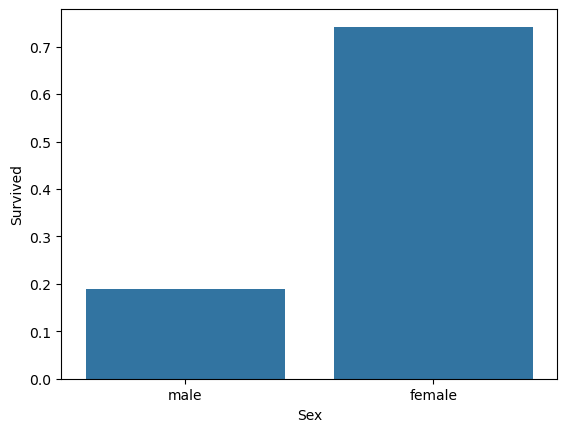

In [9]:
sns.barplot(data=train_df, x='Sex', y='Survived', errorbar=None);

In [10]:
# Посмотрим, как влияет пол человека и класс билета (Pclass) на выживаемость
train_df.groupby(['Sex', 'Pclass'])['Survived'].agg(['count', 'mean'])

count      mean
Sex    Pclass                 
female 1          94  0.968085
       2          76  0.921053
       3         144  0.500000
male   1         122  0.368852
       2         108  0.157407
       3         347  0.135447

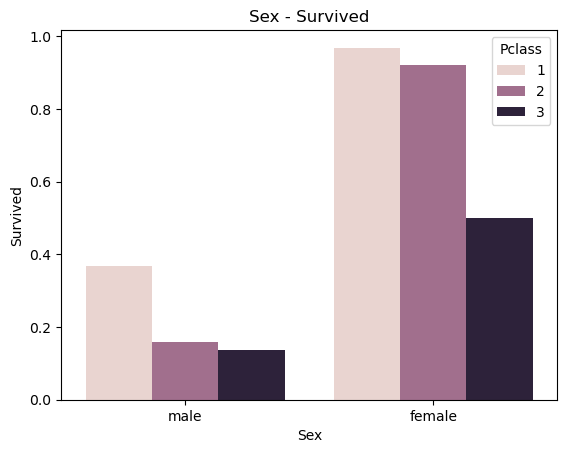

In [11]:
# Посмотрим, как влияет пол человека и класс билета (Pclass) на выживаемость
sns.barplot(x="Sex", y="Survived", hue="Pclass", data=train_df, errorbar=None)
plt.title("Sex - Survived");

In [12]:
# выживаемость по количеству родственников ( супруг/супруга и брат/сестра)
# на борту
train_df.groupby(['SibSp'], as_index=False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [13]:
# выживаемость по количеству родственников ( родители/дети) на борту
train_df.groupby(['Parch'], as_index=False)['Survived'].mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


In [14]:
# Создадим признаки, связанные с семьёй

def create_family_features(df):

    # Размер семьи
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

    # Группировка размера семьи
    def family_group(size):
        if size == 1:
            return 'Alone'
        elif size <= 4:
            return 'Small'
        elif size <= 6:
            return 'Medium'
        else:
            return 'Large'

    df['Family_Size_Grouped'] = df['Family_Size'].apply(family_group)

    return df


# Применяем к train и test
train_df = create_family_features(train_df)
test_df = create_family_features(test_df)


# Проверим выживаемость по группам
train_df.groupby('Family_Size_Grouped', as_index=False)['Survived'].mean()

,Family_Size_Grouped,Survived
0,Alone,0.303538
1,Large,0.160000
2,Medium,0.162162
3,Small,0.578767


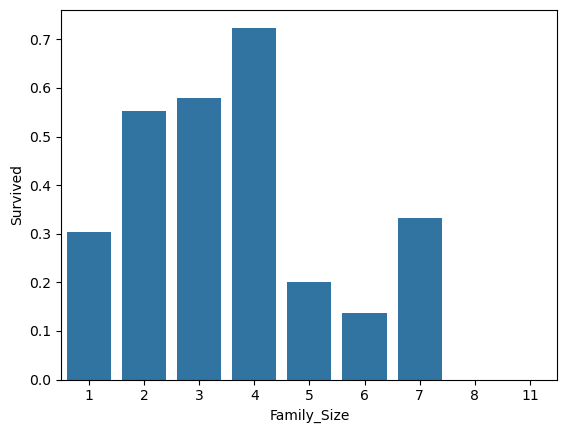

In [15]:
# Посмотрим выживаемость в зависимости от размера семьи
sns.barplot(data=train_df, x='Family_Size', y='Survived', errorbar=None);

In [16]:
# выживаемость по порту посадки
train_df.groupby(['Embarked'], as_index=False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


In [17]:
# Поработаем с Age
def create_age_features(train_df, test_df, n_bins=8):

    # Заполняем пропуски медианой из train
    median_age = train_df['Age'].median()

    train_df['Age'] = train_df['Age'].fillna(median_age)
    test_df['Age'] = test_df['Age'].fillna(median_age)

    # Создаём бины по train
    _, bins = pd.qcut(train_df['Age'], q=n_bins, retbins=True, duplicates='drop')

    bins[[0, -1]] = [-np.inf, np.inf]

    # Применяем бины
    train_df['Age_Bin'] = pd.cut(train_df['Age'], bins=bins, labels=False, include_lowest=True)
    test_df['Age_Bin'] = pd.cut(test_df['Age'], bins=bins, labels=False, include_lowest=True)

    # Переведем в категориальные признаки
    train_df['Age_Bin'] = train_df['Age_Bin'].astype('object')
    test_df['Age_Bin'] = test_df['Age_Bin'].astype('object')

    return train_df, test_df


train_df, test_df = create_age_features(train_df, test_df)

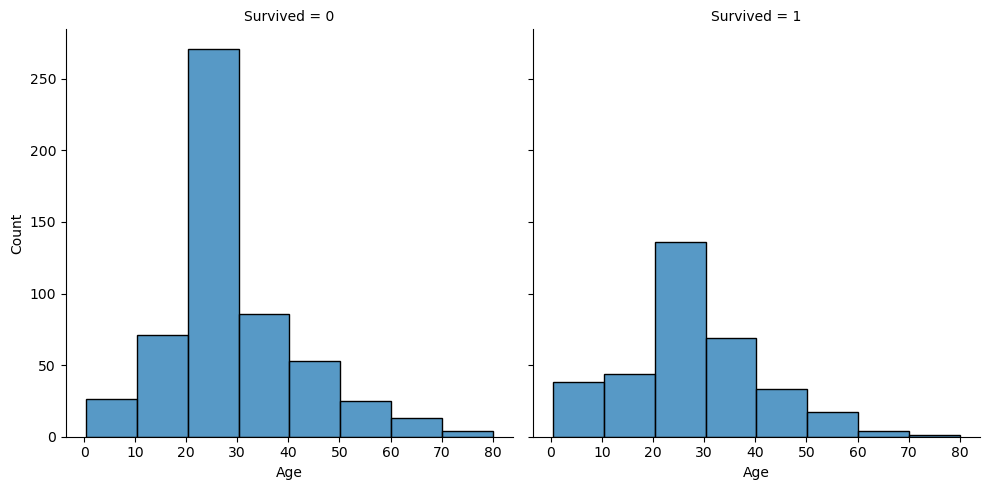

In [18]:
# Выживаемость по возрасту
sns.displot(train_df, x='Age', col='Survived', binwidth=10, height=5);

In [19]:
# Поработаем с Fare
def create_fare_features(train_df, test_df, n_bins=6):

    # Заполняем пропуск медианой по классу (Мне не нравится эта часть, надо возможно доделать чтобы вручную не указывать)
    median_fare_by_class = train_df.groupby('Pclass')['Fare'].median()

    test_df['Fare'] = test_df['Fare'].fillna(median_fare_by_class[3])

    # Создаём бины по train
    _, bins = pd.qcut(train_df['Fare'], q=n_bins, retbins=True, duplicates='drop')

    bins[[0, -1]] = [-np.inf, np.inf]

    # Применяем бины
    train_df['Fare_Bin'] = pd.cut(train_df['Fare'], bins=bins, labels=False, include_lowest=True)
    test_df['Fare_Bin'] = pd.cut(test_df['Fare'], bins=bins, labels=False, include_lowest=True)

    # Переведем в категориальные признаки
    train_df['Fare_Bin'] = train_df['Fare_Bin'].astype('object')
    test_df['Fare_Bin'] = test_df['Fare_Bin'].astype('object')


    return train_df, test_df


train_df, test_df = create_fare_features(train_df, test_df)

In [20]:
# Поработаем с Name, достанем титулы и соц статус и сохраним в отдельную колонку

def create_title_features(df):

    # Достаём титул
    df['Title'] = (
        df['Name']
        .str.split(',', expand=True)[1]
        .str.split('.', expand=True)[0]
        .str.strip()
    )

    # Объединяем редкие титулы
    title_map = {
        'Capt': 'Military',
        'Col': 'Military',
        'Major': 'Military',

        'Jonkheer': 'Noble',
        'the Countess': 'Noble',
        'Don': 'Noble',
        'Lady': 'Noble',
        'Sir': 'Noble',

        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Mrs'
    }

    df['Title'] = df['Title'].replace(title_map)

    return df


train_df = create_title_features(train_df)
test_df = create_title_features(test_df)

In [21]:
train_df.groupby(['Title'], as_index=False)['Survived'].agg(['count','mean'])

,Title,count,mean
0,Dr,7,0.428571
1,Master,40,0.575000
2,Military,5,0.400000
3,Miss,185,0.702703
4,Mr,517,0.156673
5,Mrs,126,0.793651
6,Noble,5,0.600000
7,Rev,6,0.000000


In [22]:
# Поработаем с 'Cabin'
def process_cabin(df):
    # 1. факт наличия Cabin (до любых замен)
    df['Cabin_known'] = df['Cabin'].notna().astype(int)

    # 2. количество кают (до fillna('U'))
    df['Cabin_count'] = df['Cabin'].fillna('').apply(
        lambda x: len(x.split()) if x != '' else 0
    )

    # 3. заполняем пропуски
    df['Cabin'] = df['Cabin'].fillna('U')

    # 4. палуба
    df['Deck'] = df['Cabin'].str[0]

    return df

train_df = process_cabin(train_df)
test_df = process_cabin(test_df)

In [23]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PassengerId          891 non-null    int64  
 1   Survived             891 non-null    int64  
 2   Pclass               891 non-null    int64  
 3   Name                 891 non-null    object 
 4   Sex                  891 non-null    object 
 5   Age                  891 non-null    float64
 6   SibSp                891 non-null    int64  
 7   Parch                891 non-null    int64  
 8   Ticket               891 non-null    object 
 9   Fare                 891 non-null    float64
 10  Cabin                891 non-null    object 
 11  Embarked             889 non-null    object 
 12  Family_Size          891 non-null    int64  
 13  Family_Size_Grouped  891 non-null    object 
 14  Age_Bin              891 non-null    object 
 15  Fare_Bin             891 non-null    obj

In [24]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PassengerId          418 non-null    int64  
 1   Pclass               418 non-null    int64  
 2   Name                 418 non-null    object 
 3   Sex                  418 non-null    object 
 4   Age                  418 non-null    float64
 5   SibSp                418 non-null    int64  
 6   Parch                418 non-null    int64  
 7   Ticket               418 non-null    object 
 8   Fare                 418 non-null    float64
 9   Cabin                418 non-null    object 
 10  Embarked             418 non-null    object 
 11  Family_Size          418 non-null    int64  
 12  Family_Size_Grouped  418 non-null    object 
 13  Age_Bin              418 non-null    object 
 14  Fare_Bin             418 non-null    object 
 15  Title                418 non-null    obj

In [25]:
train_df.shape, test_df.shape

((891, 20), (418, 19))

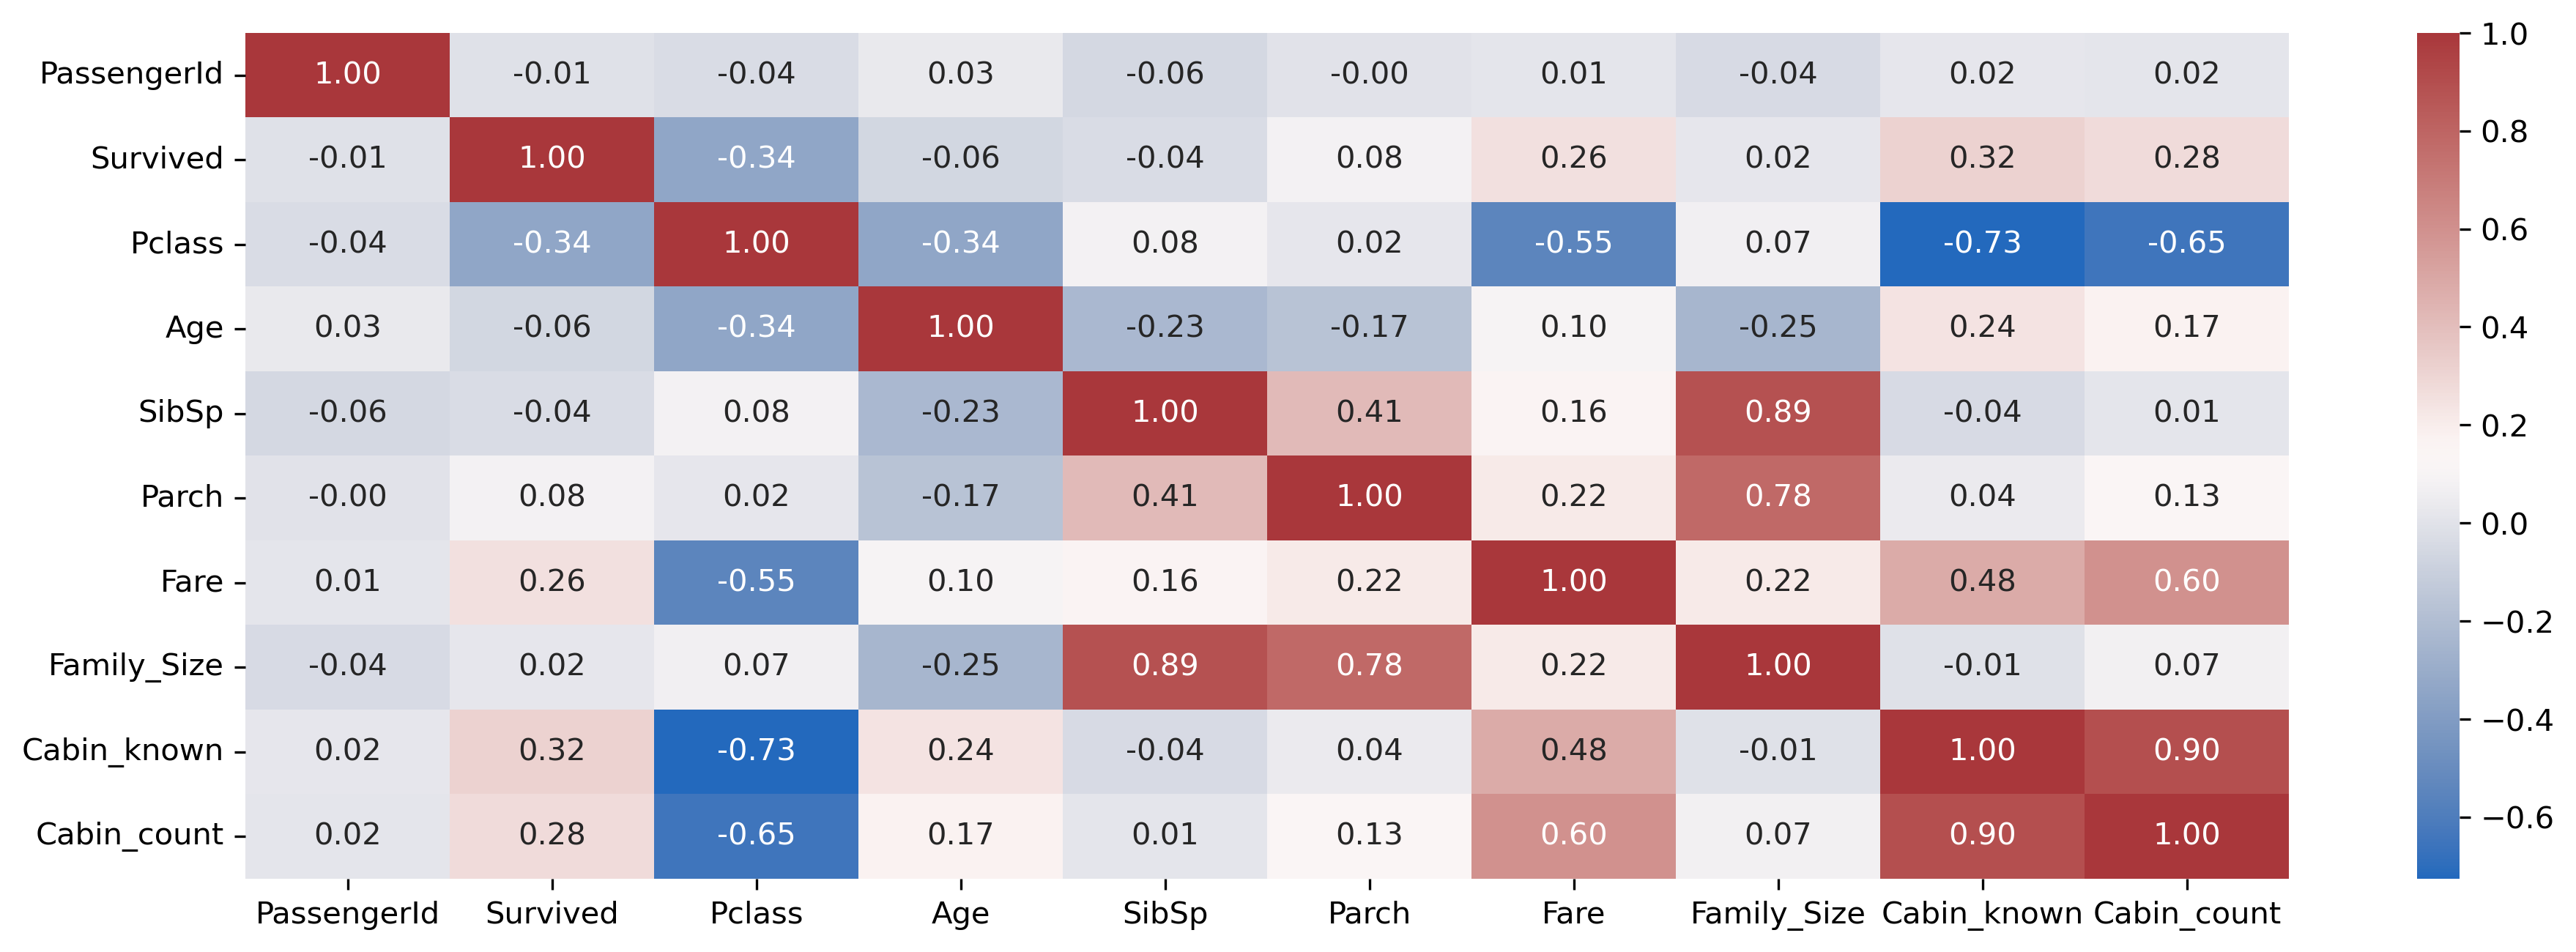

In [26]:
# Посмотрим корреляцию между числовыми признаками
num_df = train_df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(15, 5), dpi=300)
sns.heatmap(num_df.corr(), cmap="vlag", annot=True, fmt=".2f");

## Вывод по главе 2. EDA & Feature Engineering

В ходе разведочного анализа данных были изучены основные характеристики пассажиров и выявлены факторы, оказывающие наибольшее влияние на вероятность выживания.

Основные результаты анализа:

- Пол пассажира оказался одним из наиболее информативных признаков: женщины выживали значительно чаще мужчин.
- Класс обслуживания (`Pclass`) существенно влиял на выживаемость: пассажиры первого класса имели более высокие шансы на спасение по сравнению с пассажирами второго и третьего классов.
- Возраст пассажиров также связан с вероятностью выживания: дети в среднем спасались чаще взрослых.
- Размер семьи оказывал нелинейное влияние на целевую переменную. Наиболее благоприятными оказались небольшие семьи, тогда как одиночные пассажиры и пассажиры из очень больших семей выживали реже.
- В данных были обнаружены пропуски в признаках `Age`, `Cabin`, `Embarked` и `Fare`, что потребовало их дополнительной обработки.
- Анализ признака `Cabin` показал, что наличие информации о каюте может косвенно отражать социальный статус пассажира и содержать полезную информацию для прогнозирования.
- Из признака `Name` были извлечены титулы пассажиров, позволяющие учесть социальные, возрастные и гендерные особенности.

На этапе Feature Engineering были созданы новые признаки:

- `Family_Size` — общий размер семьи пассажира;
- `Family_Size_Grouped` — категория размера семьи;
- `Is_Alone` — индикатор одиночного путешествия;
- `Title` — титул, извлечённый из имени;
- `Age_Bin` — возрастная категория;
- `Fare_Bin` — категория стоимости билета;
- `Cabin_Known` — наличие информации о каюте;
- `Deck` — палуба, определённая по номеру каюты.

В результате был сформирован расширенный набор признаков, который позволил сохранить важную информацию о пассажирах и подготовить данные для дальнейшего этапа предобработки и построения моделей машинного обучения.

## 3. Preprocessing

In [27]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family_Size',
       'Family_Size_Grouped', 'Age_Bin', 'Fare_Bin', 'Title', 'Cabin_known',
       'Cabin_count', 'Deck'],
      dtype='object')

In [28]:
# Определим способы кодирования и заполнения пропусков
# Закодируем признаки Family_Size_Grouped, в них есть порядок, зададим его вручную, чтобы не слетел

ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ordinal_encoder = OrdinalEncoder(categories=[['Alone', 'Small', 'Medium', 'Large']], handle_unknown='use_encoded_value', unknown_value=-1)
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

In [29]:
# Определим колонки для кодирования

ode_cols = ['Family_Size_Grouped']
ohe_cols = ['Sex', 'Embarked', 'Title', 'Deck', 'Age_Bin', 'Fare_Bin']
num_cols = ['Age', 'Fare', 'Pclass', 'Family_Size', 'Cabin_known', 'Cabin_count']

In [30]:
# Сделаем Pipeline для обработки разных типов данных

num_pipeline = Pipeline([('imputer', num_imputer), ('scaler', StandardScaler())])

ohe_pipeline = Pipeline([('imputer', cat_imputer), ('encoder', ohe_encoder)])

ode_pipeline = Pipeline([('imputer', cat_imputer), ('encoder', ordinal_encoder)])

In [31]:
# Собираем  ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('ohe', ohe_pipeline, ohe_cols),
    ('ode', ode_pipeline, ode_cols)
])
preprocessor

,transformers,"[('num', ...), ('ohe', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [32]:
# Выберем колонки для построения моделей

X = train_df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1)
y = train_df['Survived']
X_test = test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1)

In [33]:
# Разделим X на обучение и валидацию
# Пока не делаем будет кросс валидация
# X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify = y, random_state=RANDOM_STATE)

# Сделаем кросс-валидацию так как данных мало
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Вывод по главе 3. Preprocessing

На этапе предобработки данные были подготовлены для обучения моделей машинного обучения с использованием единого пайплайна обработки признаков.

Для числовых признаков (`Age`, `Fare`, `Pclass`, `Family_Size`, `Cabin_known`, `Cabin_count`) пропущенные значения заполнялись медианой, после чего выполнялось масштабирование с помощью `StandardScaler`. Это позволило привести признаки к единому масштабу и повысить эффективность алгоритмов, чувствительных к диапазону значений.

Категориальные признаки (`Sex`, `Embarked`, `Title`, `Deck`, `Age_Bin`, `Fare_Bin`) были обработаны методом One-Hot Encoding, что обеспечило их корректное использование большинством моделей машинного обучения. Для признака `Family_Size_Grouped`, имеющего естественный порядок категорий, было применено порядковое кодирование (`Ordinal Encoding`).

Все этапы обработки были объединены в единый `ColumnTransformer` и `Pipeline`, что позволило исключить утечку данных и обеспечить одинаковую процедуру подготовки как для обучения, так и для последующей оценки моделей.

В результате был сформирован итоговый набор признаков без пропусков и в числовом формате, полностью готовый для построения и сравнения моделей классификации.

## 4. Baselines

In [34]:
# Для сохранения результатов
search_results = []

### 4.1 KNN

In [35]:
# Построим KNN

knn = KNeighborsClassifier()

# Сделаем Pipeline
model_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', knn)
])

knn_scores = cross_val_score(model_knn, X, y, cv=cv, scoring='accuracy')

print(knn_scores)
print(knn_scores.mean())

[0.82681564 0.80337079 0.84269663 0.81460674 0.8258427 ]
0.822666499278137


In [36]:
# Поищем лучшие настройки

param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]
}

grid_search_knn = GridSearchCV(
    estimator=model_knn,
    param_grid=param_grid_knn,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_knn.fit(X, y)

search_results.append({
    'Model': 'KNN',
    'Best Accuracy': grid_search_knn.best_score_,
    'Best Params': grid_search_knn.best_params_
})

print(grid_search_knn.best_params_)
print(grid_search_knn.best_score_)

{'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'uniform'}
0.822666499278137


### 4.2 Logistic Regression

In [37]:
# Построим Logistic Regression

logreg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

# Сделаем Pipeline
model_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', logreg)
])

logreg_scores = cross_val_score(model_logreg, X, y, cv=cv, scoring='accuracy')

print(logreg_scores)
print(logreg_scores.mean())

[0.83798883 0.80337079 0.83707865 0.82022472 0.84269663]
0.8282719226664993


In [38]:
# Поищем лучшие настройки

param_grid_logreg = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

grid_search_logreg = GridSearchCV(
    estimator=model_logreg,
    param_grid=param_grid_logreg,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_logreg.fit(X, y)

search_results.append({
    'Model': 'Logistic Regression',
    'Best Accuracy': grid_search_logreg.best_score_,
    'Best Params': grid_search_logreg.best_params_
})

print(grid_search_logreg.best_params_)
print(grid_search_logreg.best_score_)

{'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
0.8293955181721172


### 4.3 Naive Bayes

In [39]:
# Построим Naive Bayes

nb = GaussianNB()

# Сделаем Pipeline
model_nb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', nb)
])

nb_scores = cross_val_score(model_nb, X, y, cv=cv, scoring='accuracy')

print(nb_scores)
print(nb_scores.mean())

[0.38547486 0.74719101 0.64606742 0.62359551 0.71348315]
0.6231623877973762


In [40]:
# Поищем лучшие настройки

param_grid_nb = {
    'classifier__var_smoothing': np.logspace(-12, -6, 7)
}

grid_search_nb = GridSearchCV(
    estimator=model_nb,
    param_grid=param_grid_nb,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_nb.fit(X, y)

search_results.append({
    'Model': 'GaussianNB',
    'Best Accuracy': grid_search_nb.best_score_,
    'Best Params': grid_search_nb.best_params_
})

print(grid_search_nb.best_params_)
print(grid_search_nb.best_score_)

{'classifier__var_smoothing': np.float64(1e-06)}
0.7452513966480447


### 4.4 SVC

In [41]:
# Построим SVC

svc = SVC(random_state=RANDOM_STATE)

# Сделаем Pipeline
model_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svc)
])

svc_scores = cross_val_score(model_svc, X, y, cv=cv, scoring='accuracy')

print(svc_scores)
print(svc_scores.mean())

[0.84357542 0.81460674 0.84269663 0.81460674 0.83707865]
0.8305128366078713


In [42]:
# Поищем лучшие настройки

# param_grid = {
#     'classifier__C': [0.1, 1, 10, 100],
#     'classifier__kernel': ['linear', 'rbf'],
#     'classifier__gamma': ['scale', 'auto']
# }

# Подберём для ядра rbf, так как rbf победил
param_grid_svc = {
    'classifier__C': [0.5, 1, 2, 5, 10, 20],
    'classifier__gamma': [0.001, 0.01, 0.1, 1],
    'classifier__kernel': ['rbf']
}

grid_search_svc = GridSearchCV(
    estimator=model_svc,
    param_grid=param_grid_svc,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svc.fit(X, y)

search_results.append({
    'Model': 'SVC',
    'Best Accuracy': grid_search_svc.best_score_,
    'Best Params': grid_search_svc.best_params_
})

print(grid_search_svc.best_params_)
print(grid_search_svc.best_score_)

{'classifier__C': 2, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
0.8327788588286987


### 4.5 Decision Tree

In [43]:
# Построим Decision Tree

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Сделаем Pipeline
model_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', tree)
])

tree_scores = cross_val_score(model_tree, X, y, cv=cv, scoring='accuracy')

print(tree_scores)
print(tree_scores.mean())

[0.7877095  0.78089888 0.84269663 0.75842697 0.79775281]
0.793496955621116


In [44]:
# Поищем лучшие настройки

param_grid_tree = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__criterion': ['gini', 'entropy']
}

grid_search_tree = GridSearchCV(
    estimator=model_tree,
    param_grid=param_grid_tree,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_tree.fit(X, y)

search_results.append({
    'Model': 'DecisionTreeClassifier',
    'Best Accuracy': grid_search_tree.best_score_,
    'Best Params': grid_search_tree.best_params_
})

print(grid_search_tree.best_params_)
print(grid_search_tree.best_score_)

{'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 20}
0.828278199736363


### 4.6 Random Forest

In [45]:
# Построим Random Forest

rf = RandomForestClassifier(random_state=RANDOM_STATE)

# Сделаем Pipeline
model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

rf_scores = cross_val_score(model_rf, X, y, cv=cv, scoring='accuracy')

print(rf_scores)
print(rf_scores.mean())

[0.81564246 0.81460674 0.82022472 0.81460674 0.80337079]
0.8136902893729208


In [46]:
# Поищем лучшие настройки

param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X, y)

search_results.append({
    'Model': 'RandomForestClassifier',
    'Best Accuracy': grid_search_rf.best_score_,
    'Best Params': grid_search_rf.best_params_
})

print(grid_search_rf.best_params_)
print(grid_search_rf.best_score_)

{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
0.8350323269097985


### 4.7 Gradient Boosting

In [47]:
# Построим Gradient Boosting

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

# Pipeline
model_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gb)
])

gb_scores = cross_val_score(model_gb, X, y, cv=cv, scoring='accuracy')

print(gb_scores)
print(gb_scores.mean())

[0.82122905 0.8258427  0.83707865 0.83707865 0.84269663]
0.8327851358985624


In [48]:
# Поищем лучшие настройки

param_grid_gb = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search_gb = GridSearchCV(
    estimator=model_gb,
    param_grid=param_grid_gb,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_gb.fit(X, y)

search_results.append({
    'Model': 'GradientBoostingClassifier',
    'Best Accuracy': grid_search_gb.best_score_,
    'Best Params': grid_search_gb.best_params_
})

print(grid_search_gb.best_params_)
print(grid_search_gb.best_score_)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
0.8429037725189881


### 4.8 Результаты

In [49]:
results = pd.DataFrame({
    'Model': [
        'KNN',
        'Logistic Regression',
        'GaussianNB',
        'SVC',
        'DecisionTreeClassifier',
        'RandomForestClassifier',
        'GradientBoostingClassifier'
    ],
    'Accuracy': [
        knn_scores.mean(),
        logreg_scores.mean(),
        nb_scores.mean(),
        svc_scores.mean(),
        tree_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean()
    ]
})

results.sort_values('Accuracy', ascending=False)

,Model,Accuracy
6,GradientBoostingClassifier,0.832785
3,SVC,0.830513
1,Logistic Regression,0.828272
0,KNN,0.822666
5,RandomForestClassifier,0.813690
4,DecisionTreeClassifier,0.793497
2,GaussianNB,0.623162


In [50]:
#  Результаты после подбора параметров

results = pd.DataFrame(search_results)
results.sort_values(by='Best Accuracy', ascending=False).reset_index(drop=True)

,Model,Best Accuracy,Best Params
0,GradientBoostingClassifier,0.842904,"{'classifier__learning_rate': 0.1, 'classifier..."
1,RandomForestClassifier,0.835032,"{'classifier__max_depth': 10, 'classifier__min..."
2,SVC,0.832779,"{'classifier__C': 2, 'classifier__gamma': 0.1,..."
3,Logistic Regression,0.829396,"{'classifier__C': 1, 'classifier__penalty': 'l..."
4,DecisionTreeClassifier,0.828278,"{'classifier__criterion': 'gini', 'classifier_..."
5,KNN,0.822666,"{'classifier__n_neighbors': 5, 'classifier__p'..."
6,GaussianNB,0.745251,{'classifier__var_smoothing': 1e-06}


### Вывод по главе

В данной главе было проведено сравнение нескольких алгоритмов машинного обучения для решения задачи прогнозирования выживаемости пассажиров «Титаника». Для оценки качества моделей использовалась кросс-валидация с метрикой Accuracy.

На первом этапе были обучены базовые версии моделей без подбора гиперпараметров. Лучшие результаты показали модели Gradient Boosting, SVC и Logistic Regression. Наименьшее качество продемонстрировал алгоритм Gaussian Naive Bayes, что связано с его предположениями о независимости признаков и нормальности их распределения.

На втором этапе для каждой модели был выполнен подбор гиперпараметров с помощью `GridSearchCV`. Полученные результаты показали, что настройка параметров позволила улучшить качество большинства алгоритмов.

| Модель | Accuracy (до настройки) | Accuracy (после настройки) |
|---------|---------:|---------:|
| KNN | 0.823 | 0.823 |
| Logistic Regression | 0.828 | 0.829 |
| GaussianNB | 0.623 | 0.745 |
| SVC | 0.831 | 0.833 |
| Decision Tree | 0.793 | 0.828 |
| Random Forest | 0.814 | 0.835 |
| Gradient Boosting | **0.833** | **0.843** |

Наибольший прирост качества продемонстрировали модели Random Forest, Decision Tree и Gaussian Naive Bayes. Для Logistic Regression и SVC улучшение оказалось незначительным, что свидетельствует о хороших результатах моделей уже при стандартных настройках.

По итогам проведённого сравнения наилучший результат показала модель **Gradient Boosting Classifier**, достигнув значения Accuracy **0.843** после подбора гиперпараметров. 

## 5. CatBoost, LightGBM, XGBoost

In [51]:
# Сделаем список для хранения результатов
boosting_results = []

### 5.1 CatBoost

In [52]:
# Построим CatBoost

cat = CatBoostClassifier(
    random_state=RANDOM_STATE,
    verbose=False
)

model_cat = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', cat)
])

cat_scores = cross_val_score(model_cat, X, y, cv=cv, scoring='accuracy')

print(cat_scores)
print(cat_scores.mean())

[0.82122905 0.83146067 0.84269663 0.83146067 0.86516854]
0.8384031134266523


In [53]:
# Поищем лучшие параметры

param_grid_cat = {
    'classifier__iterations': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__depth': [3, 4, 5, 6],
    'classifier__l2_leaf_reg': [1, 3, 5, 7]
}

grid_search_cat = GridSearchCV(
    estimator=model_cat,
    param_grid=param_grid_cat,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_cat.fit(X, y)

boosting_results.append({
    'Model': 'CatBoost',
    'Best Accuracy': grid_search_cat.best_score_,
    'Best Params': grid_search_cat.best_params_
})

print(grid_search_cat.best_params_)
print(grid_search_cat.best_score_)

{'classifier__depth': 4, 'classifier__iterations': 300, 'classifier__l2_leaf_reg': 7, 'classifier__learning_rate': 0.05}
0.8439959826752872


### 5.2 LightGBM

In [54]:
# Построим LightGBM

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names"
)

lgbm = LGBMClassifier(
    random_state=RANDOM_STATE,
    verbose=-1
)

model_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgbm)
])

lgbm_scores = cross_val_score(model_lgbm, X, y, cv=cv, scoring='accuracy')

print(lgbm_scores)
print(lgbm_scores.mean())

[0.82122905 0.8258427  0.81460674 0.80898876 0.82022472]
0.8181783943255286


In [55]:
# Поищем лучшие параметры

param_grid_lgbm = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2, 3, 4, -1],
    'classifier__num_leaves': [7, 15, 31],
    'classifier__min_child_samples': [5, 10, 20]
}

grid_search_lgbm = GridSearchCV(
    estimator=model_lgbm,
    param_grid=param_grid_lgbm,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_lgbm.fit(X, y)

boosting_results.append({
    'Model': 'LightGBM',
    'Best Accuracy': grid_search_lgbm.best_score_,
    'Best Params': grid_search_lgbm.best_params_
})

print(grid_search_lgbm.best_params_)
print(grid_search_lgbm.best_score_)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__min_child_samples': 5, 'classifier__n_estimators': 200, 'classifier__num_leaves': 7}
0.840631473228297


### 5.3 XGBoost

In [56]:
# Построим XGBoost

xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])

xgb_scores = cross_val_score(model_xgb, X, y, cv=cv, scoring='accuracy')

print(xgb_scores)
print(xgb_scores.mean())


[0.81564246 0.82022472 0.80898876 0.78089888 0.82022472]
0.8091959073504487


In [57]:
# Поищем лучшие параметры

param_grid_xgb = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [2, 3, 4],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_xgb.fit(X, y)

boosting_results.append({
    'Model': 'XGBoost',
    'Best Accuracy': grid_search_xgb.best_score_,
    'Best Params': grid_search_xgb.best_params_
})

print(grid_search_xgb.best_params_)
print(grid_search_xgb.best_score_)

{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
0.8450881928315862


### 5.4 Результаты

In [58]:
#  Результаты после подбора параметров

boosting_results_df = pd.DataFrame(boosting_results)
boosting_results_df.sort_values('Best Accuracy', ascending=False)

,Model,Best Accuracy,Best Params
2,XGBoost,0.845088,"{'classifier__colsample_bytree': 1.0, 'classif..."
0,CatBoost,0.843996,"{'classifier__depth': 4, 'classifier__iteratio..."
1,LightGBM,0.840631,"{'classifier__learning_rate': 0.1, 'classifier..."


### 5.5 Вывод по главе 5

В данной главе были исследованы современные алгоритмы градиентного бустинга: CatBoost, LightGBM и XGBoost. Для каждой модели была проведена первоначальная оценка качества, после чего выполнен подбор гиперпараметров с использованием GridSearchCV.

Таблица 5.4 – Результаты моделей градиентного бустинга

| Модель | Accuracy |
|---------|----------|
| CatBoost | 0.844 |
| XGBoost | **0.845** |
| LightGBM | 0.841 |

По результатам экспериментов наилучшее качество продемонстрировала модель XGBoost с точностью 0.845. Незначительно уступила ей модель CatBoost с результатом 0.844. LightGBM также показала высокий уровень качества, однако её итоговая точность оказалась немного ниже и составила 0.841.Подбор гиперпараметров позволил улучшить качество всех моделей по сравнению с их базовыми версиями.

Сравнение с результатами предыдущей главы показывает, что современные реализации градиентного бустинга позволили получить небольшое улучшение качества по сравнению с классическими алгоритмами машинного обучения.


## 6. Feature Importance with SHAP

### 6.1 Подготовка данных для SHAP

In [59]:
# SHAP работает с признаками после обработки препроцессором
# Так как OneHotEncoder задан с sparse_output=False,
# после препроцессинга получаем обычный массив, который можно преобразовать в DataFrame.

# Преобразуем исходные данные
X_transformed = preprocessor.fit_transform(X)

# Получаем названия признаков после обработки
feature_names = preprocessor.get_feature_names_out()

# Создаём DataFrame для удобства анализа
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

print(f'Количество признаков после обработки: {X_transformed_df.shape[1]}')
X_transformed_df.head()

Количество признаков после обработки: 43


,num__Age,num__Fare,num__Pclass,num__Family_Size,num__Cabin_known,num__Cabin_count,ohe__Sex_female,ohe__Sex_male,ohe__Embarked_C,ohe__Embarked_Q,...,ohe__Age_Bin_5,ohe__Age_Bin_6,ohe__Age_Bin_7,ohe__Fare_Bin_0,ohe__Fare_Bin_1,ohe__Fare_Bin_2,ohe__Fare_Bin_3,ohe__Fare_Bin_4,ohe__Fare_Bin_5,ode__Family_Size_Grouped
0,-0.565736,-0.502445,0.827377,0.059160,-0.544925,-0.488483,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.663861,0.786845,-1.566107,0.059160,1.835115,1.340249,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.258337,-0.488854,0.827377,-0.560975,-0.544925,-0.488483,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.433312,0.420730,-1.566107,0.059160,1.835115,1.340249,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,0.433312,-0.486337,0.827377,-0.560975,-0.544925,-0.488483,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### 6.2 Logistic Regression

In [60]:
# Получаем лучший классификатор
logreg_model = grid_search_logreg.best_estimator_.named_steps['classifier']

# Создаём SHAP-объяснитель для линейной модели
explainer_logreg = shap.LinearExplainer(
    logreg_model,
    X_transformed_df
)

# Считаем SHAP-значения
shap_values_logreg = explainer_logreg(X_transformed_df)

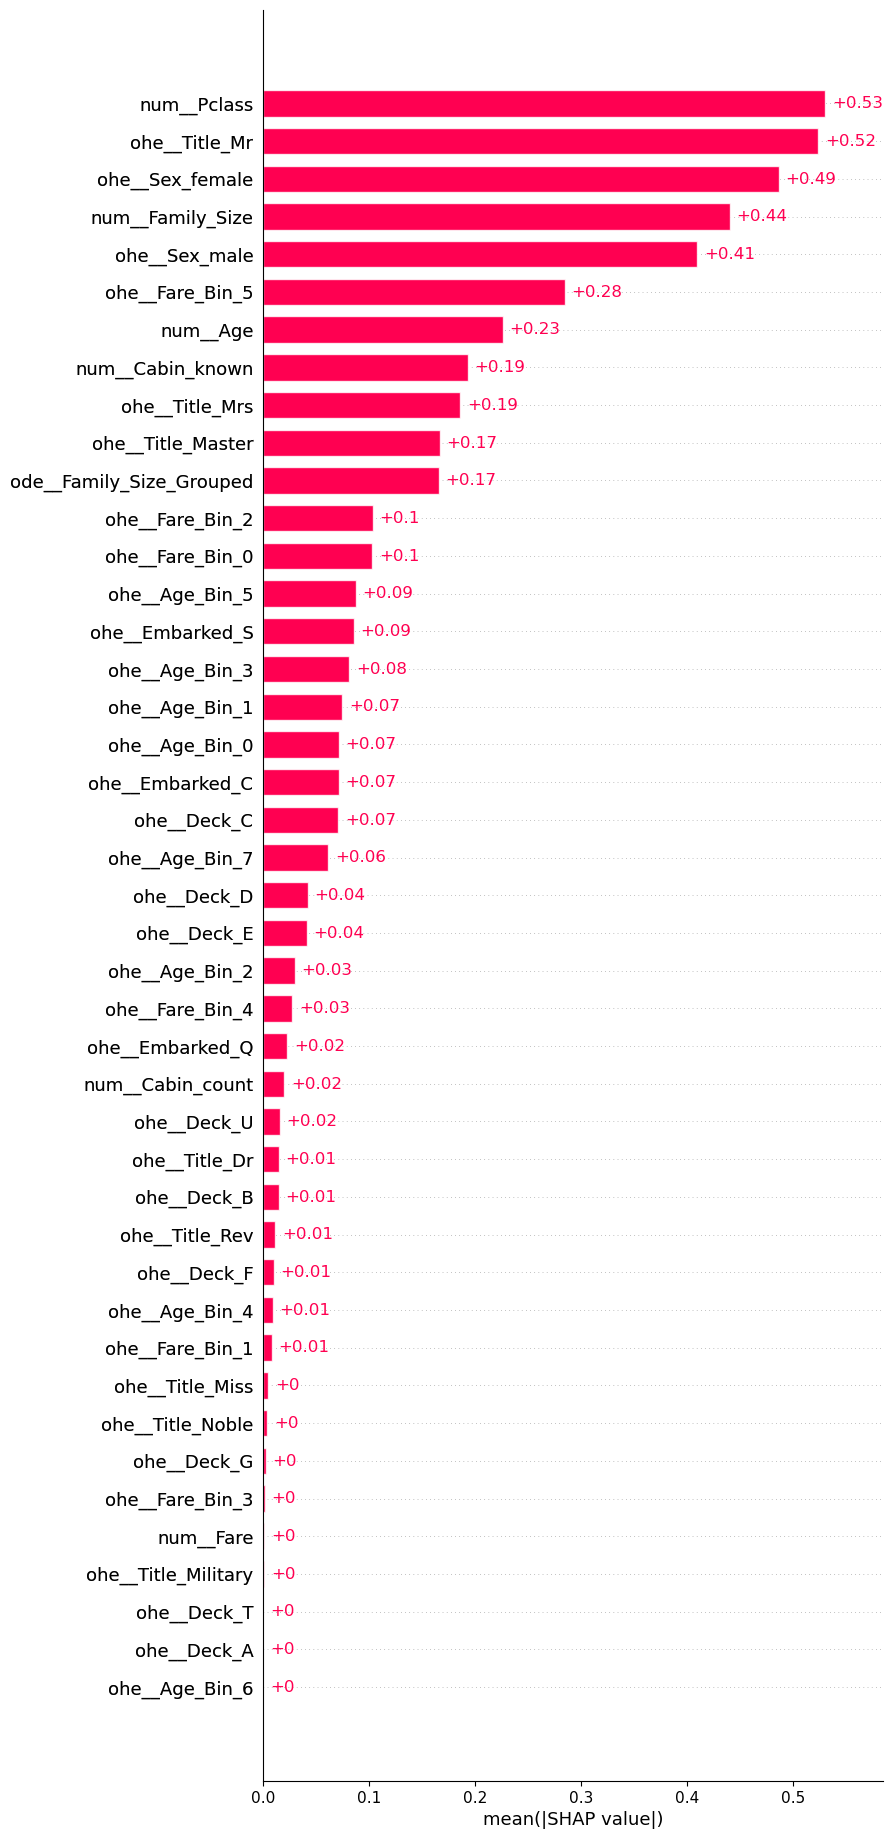

In [61]:
# Показывает самые важные признаки в модели
shap.plots.bar(
    shap_values_logreg,
    max_display=43
)

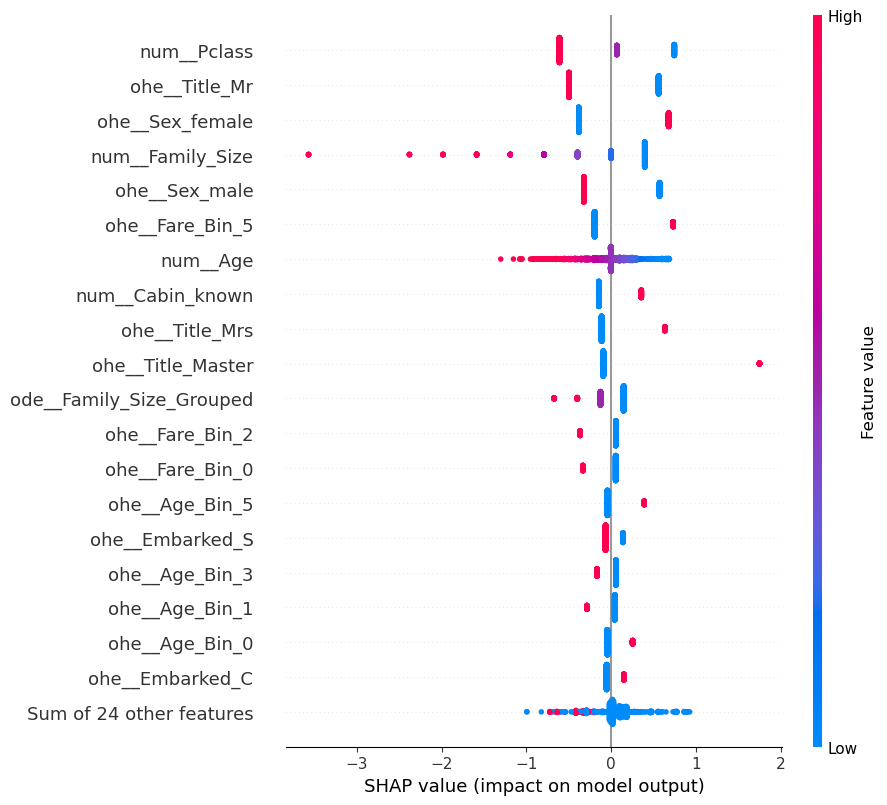

In [62]:
# Красный цвет — большое значение признака
# Синий цвет — маленькое значение признака
# Чем дальше от нуля, тем сильнее влияние

shap.plots.beeswarm(
    shap_values_logreg,
    max_display=20
)

### 6.3 Random Forest

In [63]:
# Получаем лучший классификатор
rf_model = grid_search_rf.best_estimator_.named_steps['classifier']

# Создаём объяснитель для деревьев используется TreeExplainer.
explainer_rf = shap.TreeExplainer(rf_model)

# Считаем SHAP
shap_values_rf = explainer_rf(X_transformed_df)

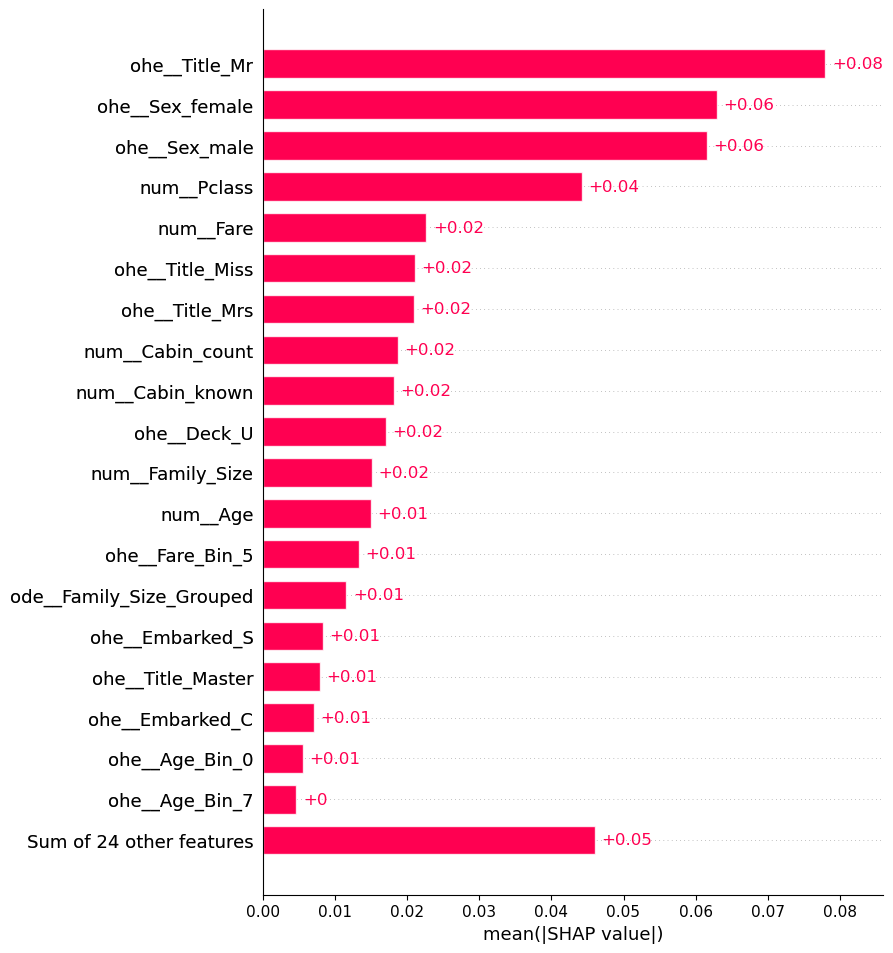

In [64]:
shap.plots.bar(shap_values_rf[:, :, 1], max_display=20)

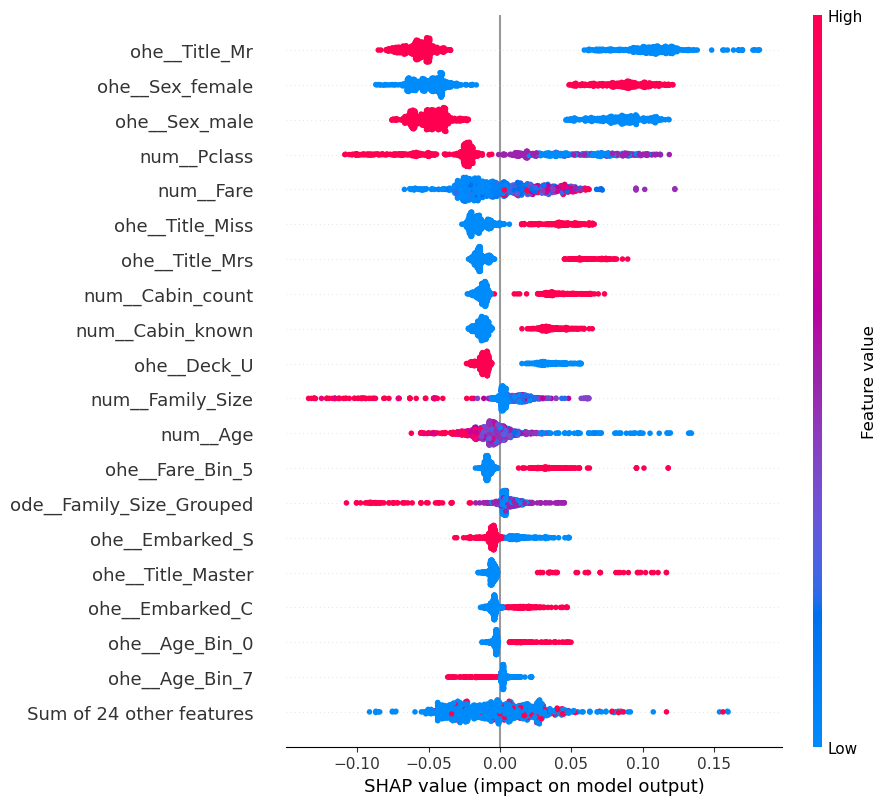

In [65]:
shap.plots.beeswarm(shap_values_rf[:, :, 1], max_display=20)

### 6.4 CatBoost

In [66]:
cat_model = grid_search_cat.best_estimator_.named_steps['classifier']

explainer_cat = shap.TreeExplainer(cat_model)

shap_values_cat = explainer_cat(X_transformed_df)

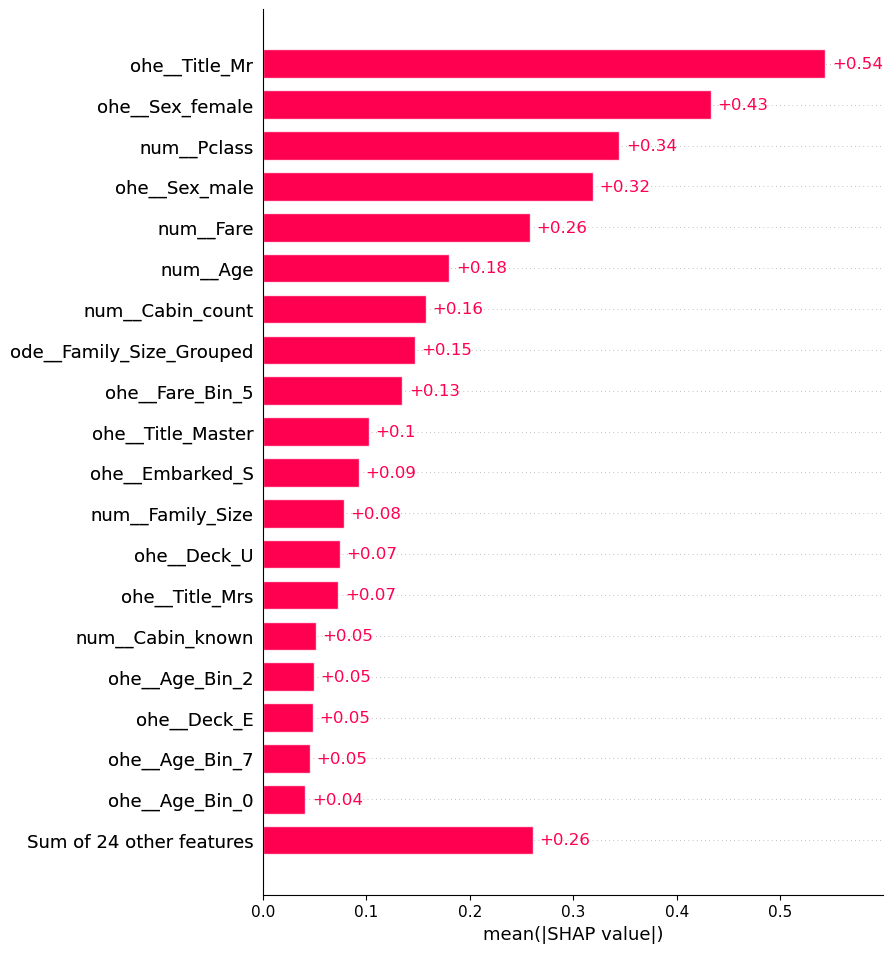

In [67]:
shap.plots.bar(shap_values_cat, max_display=20)

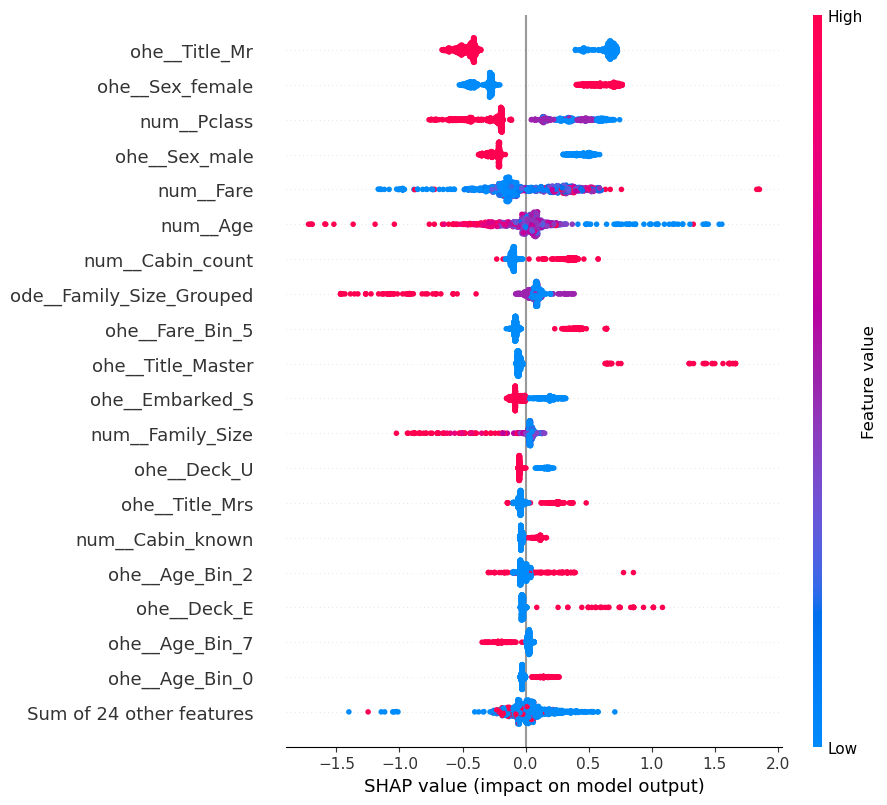

In [68]:
shap.plots.beeswarm(shap_values_cat, max_display=20)

### 6.5 LightGBM

In [69]:
lgbm_model = grid_search_lgbm.best_estimator_.named_steps['classifier']

explainer_lgbm = shap.TreeExplainer(lgbm_model)

shap_values_lgbm = explainer_lgbm(X_transformed_df)

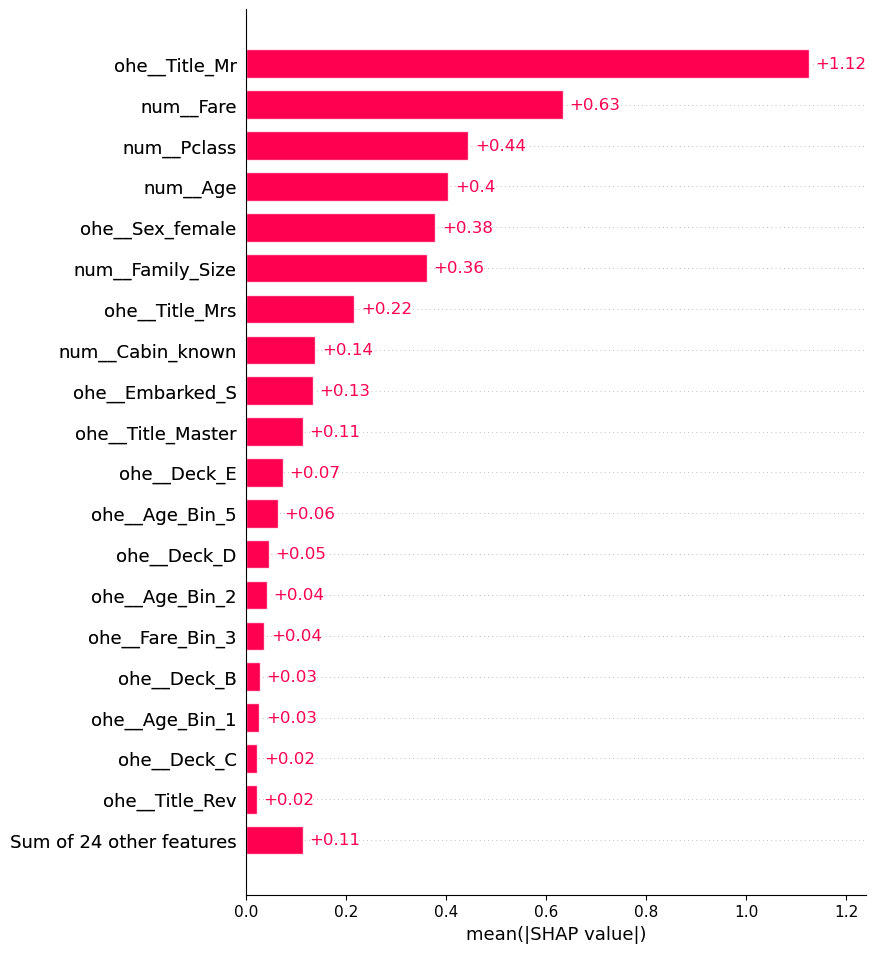

In [70]:
shap.plots.bar(shap_values_lgbm, max_display=20)

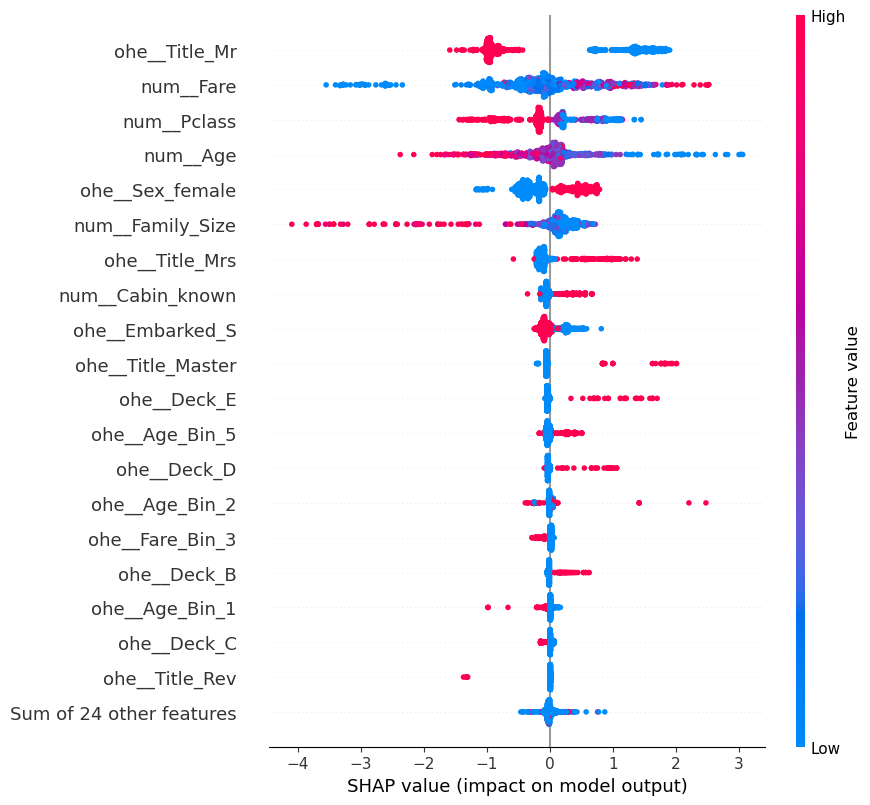

In [71]:
shap.plots.beeswarm(shap_values_lgbm, max_display=20)

In [72]:
# Logistic Regression
pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(shap_values_logreg.values).mean(axis=0)
}).sort_values('Importance', ascending=False).head(15)

,Feature,Importance
2,num__Pclass,0.530722
15,ohe__Title_Mr,0.524048
6,ohe__Sex_female,0.486454
3,num__Family_Size,0.440368
7,ohe__Sex_male,0.409809
41,ohe__Fare_Bin_5,0.284453
0,num__Age,0.226008
4,num__Cabin_known,0.193433
16,ohe__Title_Mrs,0.185964
12,ohe__Title_Master,0.166587


In [73]:
# Random Forest
pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(shap_values_rf[:, :, 1].values).mean(axis=0)
}).sort_values('Importance', ascending=False).head(15)

,Feature,Importance
15,ohe__Title_Mr,0.078016
6,ohe__Sex_female,0.062958
7,ohe__Sex_male,0.061514
2,num__Pclass,0.044241
1,num__Fare,0.022652
14,ohe__Title_Miss,0.021048
16,ohe__Title_Mrs,0.020896
5,num__Cabin_count,0.018723
4,num__Cabin_known,0.018092
27,ohe__Deck_U,0.017044


In [74]:
# CatBoost
pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(shap_values_cat.values).mean(axis=0)
}).sort_values('Importance', ascending=False).head(15)

,Feature,Importance
15,ohe__Title_Mr,0.543867
6,ohe__Sex_female,0.433086
2,num__Pclass,0.344532
7,ohe__Sex_male,0.319152
1,num__Fare,0.257814
0,num__Age,0.180124
5,num__Cabin_count,0.157251
42,ode__Family_Size_Grouped,0.146868
41,ohe__Fare_Bin_5,0.134758
12,ohe__Title_Master,0.102368


In [75]:
# LightGBM
pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(shap_values_lgbm.values).mean(axis=0)
}).sort_values('Importance', ascending=False).head(15)

,Feature,Importance
15,ohe__Title_Mr,1.124715
1,num__Fare,0.633251
2,num__Pclass,0.443940
0,num__Age,0.403708
6,ohe__Sex_female,0.378207
3,num__Family_Size,0.360853
16,ohe__Title_Mrs,0.216042
4,num__Cabin_known,0.138282
10,ohe__Embarked_S,0.133337
12,ohe__Title_Master,0.113324


### 6.6 Выводы по SHAP-анализу

Для SHAP-анализа были выбраны модели Logistic Regression, Random Forest, CatBoost и LightGBM. Данные модели поддерживают быстрые и устойчивые методы интерпретации, что позволяет наглядно оценить влияние признаков на предсказание выживания пассажиров.

Модель SVC не была включена в SHAP-анализ, поскольку для нелинейного ядра RBF требуется использование `KernelExplainer`, который значительно увеличивает время вычислений.

Модель XGBoost также не была включена в итоговый SHAP-анализ из-за несовместимости используемых версий библиотек SHAP и XGBoost при построении `TreeExplainer`.

#### Наиболее важные признаки

Результаты SHAP показали, что разные модели выделяют схожий набор наиболее значимых признаков.

Во всех моделях высокий вклад в предсказание вносили:

- `Title_Mr` (титул Mr);
- `Sex_female` и `Sex_male` (пол пассажира);
- `Pclass` (класс билета);
- `Fare` (стоимость билета);
- `Age` (возраст);
- `Family_Size` (размер семьи);
- `Family_Size_Grouped` (группировка размера семьи);
- `Cabin_known` (наличие информации о каюте);
- `Title_Mrs` (титул Mrs).

Наибольшее влияние во многих моделях оказали признаки, связанные с полом пассажира, социальным статусом пассажира (`Title`) и условиями поездки (`Pclass`, `Fare`).

Также важную роль играют признаки `Age` (возраст) и `Family_Size` (размер семьи), что указывает на наличие связи между характеристиками пассажира и вероятностью выживания.

#### Признаки средней важности

В ряде моделей заметное, но менее выраженное влияние показали следующие признаки:

- `Cabin_count` (количество кают, связанных с билетом);
- `Title_Master` (титул Master);
- `Embarked_S` (порт посадки Southampton);
- признаки палуб (`Deck_*`);
- интервалы возраста (`Age_Bin_*`);
- интервалы стоимости билета (`Fare_Bin_*`).

Данные признаки используются моделями при построении предсказаний, однако их вклад оказался ниже по сравнению с основными признаками.

#### Возможное сокращение признаков

По результатам SHAP нельзя однозначно удалять признаки, однако можно выделить признаки-кандидаты для дальнейшей проверки:

- отдельные категории признака `Embarked` (порт посадки);
- редко встречающиеся палубы (`Deck_*`);
- некоторые интервалы возраста (`Age_Bin_*`);
- некоторые интервалы стоимости билета (`Fare_Bin_*`);
- редкие значения признака `Title`.

Для принятия решения об исключении признаков необходимо провести дополнительный эксперимент и сравнить качество моделей до и после их удаления.

#### Итоговый вывод

SHAP-анализ показал, что ключевыми факторами для прогнозирования выживания пассажиров являются пол, титул, возраст, класс билета и стоимость билета. Дополнительный вклад вносят признаки, созданные на этапе Feature Engineering, такие как размер семьи и информация о каюте.

Полученные результаты согласуются между несколькими моделями, что подтверждает устойчивость выявленных закономерностей и полезность созданных признаков для решения задачи классификации.

Стоит учитывать, что признаки вида `Sex_female`, `Title_Mr`, `Embarked_S` и другие появились после применения One-Hot Encoding к исходным категориальным признакам. Поэтому SHAP оценивает важность уже преобразованных признаков, которые непосредственно используются моделями при обучении и предсказании.

## 7. Ансамблевые модели: Voting и Stacking

In [76]:
# Для сохранения результатов ансамблевых моделей
ensemble_results = []

# Подготовка лучших параметров для моделей
def get_classifier_params(grid_search):
    """Достаём лучшие параметры классификатора из Pipeline и убираем префикс classifier__."""
    return {
        key.replace('classifier__', ''): value
        for key, value in grid_search.best_params_.items()
        if key.startswith('classifier__')
    }

### 7.1 Подготовка базовых моделей для ансамблей

In [77]:
# Базовые модели с лучшими найденными параметрами
# Используем именно классификаторы, а не готовые Pipeline,
# потому что общий preprocessor будет один раз применяться внутри ансамблевого Pipeline.

logreg_ens = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    **get_classifier_params(grid_search_logreg)
)

svc_ens = SVC(
    random_state=RANDOM_STATE,
    probability=True,  # нужно для soft voting
    **get_classifier_params(grid_search_svc)
)

rf_ens = RandomForestClassifier(
    random_state=RANDOM_STATE,
    **get_classifier_params(grid_search_rf)
)

cat_ens = CatBoostClassifier(
    random_state=RANDOM_STATE,
    verbose=False,
    **get_classifier_params(grid_search_cat)
)

lgbm_ens = LGBMClassifier(
    random_state=RANDOM_STATE,
    verbose=-1,
    **get_classifier_params(grid_search_lgbm)
)

xgb_ens = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1,
    **get_classifier_params(grid_search_xgb)
)

base_estimators = [
    ('logreg', logreg_ens),
    ('svc', svc_ens),
    ('rf', rf_ens),
    ('cat', cat_ens),
    ('lgbm', lgbm_ens),
    ('xgb', xgb_ens)
]

### 7.2 VotingClassifier

VotingClassifier объединяет предсказания нескольких моделей. Проверим два варианта:

- hard — голосование по классам;
- soft — усреднение вероятностей классов.

In [78]:
# Hard Voting
voting_hard = VotingClassifier(
    estimators=base_estimators,
    voting='hard',
    n_jobs=-1
)

model_voting_hard = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', voting_hard)
])

voting_hard_scores = cross_val_score(
    model_voting_hard,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

ensemble_results.append({
    'Model': 'VotingClassifier hard',
    'Accuracy': voting_hard_scores.mean()
})

print(voting_hard_scores)
print(voting_hard_scores.mean())

[0.84916201 0.82022472 0.85955056 0.84831461 0.85955056]
0.8473604921222773


In [79]:
# Soft Voting
voting_soft = VotingClassifier(
    estimators=base_estimators,
    voting='soft',
    n_jobs=-1
)

model_voting_soft = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', voting_soft)
])

voting_soft_scores = cross_val_score(
    model_voting_soft,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

ensemble_results.append({
    'Model': 'VotingClassifier soft',
    'Accuracy': voting_soft_scores.mean()
})

print(voting_soft_scores)
print(voting_soft_scores.mean())

[0.8547486  0.82022472 0.84269663 0.83707865 0.84831461]
0.8406126420187057


### 7.3 StackingClassifier

StackingClassifier использует предсказания базовых моделей как новые признаки для финальной модели. В качестве финальной модели используем Logistic Regression и Ridge.

In [80]:
# Stacking с Logistic Regression в качестве финальной модели
stacking_logreg = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    cv=cv
)

model_stacking_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', stacking_logreg)
])

stacking_logreg_scores = cross_val_score(
    model_stacking_logreg,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

ensemble_results.append({
    'Model': 'StackingClassifier LogisticRegression',
    'Accuracy': stacking_logreg_scores.mean()
})

print(stacking_logreg_scores)
print(stacking_logreg_scores.mean())


[0.83798883 0.82022472 0.84831461 0.83707865 0.85393258]
0.839507877722679


In [81]:
# Stacking с RidgeClassifier в качестве финальной модели
stacking_ridge = StackingClassifier(
    estimators=base_estimators,
    final_estimator=RidgeClassifier(),
    cv=cv
)

model_stacking_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', stacking_ridge)
])

stacking_ridge_scores = cross_val_score(
    model_stacking_ridge,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

ensemble_results.append({
    'Model': 'StackingClassifier RidgeClassifier',
    'Accuracy': stacking_ridge_scores.mean()
})

print(stacking_ridge_scores)
print(stacking_ridge_scores.mean())

[0.83240223 0.83707865 0.84831461 0.8258427  0.85393258]
0.8395141547925429


### 7.4 Сравнение ансамблей

In [82]:
ensemble_results_df = pd.DataFrame(ensemble_results)
ensemble_results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

,Model,Accuracy
0,VotingClassifier hard,0.847360
1,VotingClassifier soft,0.840613
2,StackingClassifier RidgeClassifier,0.839514
3,StackingClassifier LogisticRegression,0.839508


In [83]:
# Сравним ансамбли с лучшими результатами классических моделей и бустингов
classic_models = (
    results[['Model', 'Best Accuracy']]
    .rename(columns={'Best Accuracy': 'Accuracy'})
)

boosting_models = (
    boosting_results_df[['Model', 'Best Accuracy']]
    .rename(columns={'Best Accuracy': 'Accuracy'})
)

all_results = pd.concat(
    [classic_models, boosting_models, ensemble_results_df],
    ignore_index=True
)

all_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

,Model,Accuracy
0,VotingClassifier hard,0.847360
1,XGBoost,0.845088
2,CatBoost,0.843996
3,GradientBoostingClassifier,0.842904
4,LightGBM,0.840631
5,VotingClassifier soft,0.840613
6,StackingClassifier RidgeClassifier,0.839514
7,StackingClassifier LogisticRegression,0.839508
8,RandomForestClassifier,0.835032
9,SVC,0.832779


## 7.5 Выводы

В данной главе были исследованы ансамблевые методы машинного обучения на основе лучших моделей, полученных на предыдущих этапах проекта. Были реализованы и протестированы различные варианты ансамблей, включая `VotingClassifier` и `StackingClassifier`.

Метод голосования (Voting) позволил объединить предсказания нескольких сильных алгоритмов, а стекинг (Stacking) дополнительно использовал мета-модель для обучения на результатах базовых классификаторов. Такой подход позволяет учитывать сильные стороны разных моделей и потенциально улучшать качество предсказаний.

По результатам кросс-валидации ансамблевые модели продемонстрировали качество, сопоставимое с лучшими отдельными алгоритмами. При этом прирост метрик оказался умеренным, поскольку объём данных относительно невелик, а основные закономерности были успешно выявлены ещё на этапах feature engineering и настройки базовых моделей.

Метод blending не рассматривался отдельно, поскольку датасет Titanic имеет небольшой размер. Выделение отдельной validation-выборки уменьшило бы объём данных для обучения базовых моделей, поэтому для ансамблирования были использованы Voting и Stacking.

Дополнительно были исследованы компактные ансамбли, состоящие из 3 моделей. Ожидалось, что уменьшение числа базовых алгоритмов и увеличение их разнообразия может улучшить качество ансамбля. Однако результаты показали, что компактные ансамбли не продемонстрировали заметного преимущества по сравнению с первоначальными вариантами. Лучший результат показал StackingClassifier на основе SVC, CatBoost и Logistic Regression, однако его преимущество оказалось незначительным. Это свидетельствует о том, что основные закономерности датасета уже были успешно извлечены базовыми моделями, а дальнейшее усложнение ансамбля приносит лишь минимальный прирост качества.

Проведённые эксперименты показали, что ансамблевые методы являются эффективным инструментом повышения устойчивости модели и позволяют получить более надёжное итоговое решение. На основе полученных результатов для дальнейшего сравнения с моделями глубокого обучения будет использована лучшая модель из рассмотренных ансамблей.

## 8. Deep Neural Network (DNN)

В этом разделе построим нейронную сеть для решения задачи бинарной классификации.

Начнем с простой полносвязной нейронной сети (MLP), а затем постепенно попробуем улучшить её архитектуру и процесс обучения:
- увеличим количество слоев;
- добавим Batch Normalization и Dropout;
- попробуем разные размеры скрытых слоев и функции активации;
- сравним оптимизаторы;
- добавим scheduler для изменения learning rate;
- поэкспериментируем с параметрами обучения.

В качестве дополнительного эксперимента попробуем использовать Embedding для категориальных признаков.

### 8.1 Подготовка данных

Для обучения нейронной сети разделим обучающие данные на train и validation выборки.

Validation выборка будет использоваться для оценки качества модели во время обучения и позволит отслеживать переобучение.

При разделении используем стратификацию по целевой переменной, чтобы сохранить соотношение классов в обеих выборках.

In [84]:
# Разделим данные на обучающую и валидационную выборки

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)

Train: (712, 13) (712,)
Validation: (179, 13) (179,)


#### Предобработка данных

Для нейронной сети применим уже созданный `preprocessor`, который использовался для классических моделей.

Обучим (`fit`) преобразования только на `X_train`, а к `X_valid` применим уже обученный preprocessor. Это позволит избежать утечки информации из validation выборки в процесс обучения.

После преобразования категориальные признаки будут закодированы, а числовые — масштабированы.

In [85]:
# Обучим preprocessor только на обучающей выборке
X_train_processed = preprocessor.fit_transform(X_train)

# Применим те же преобразования к validation выборке
X_valid_processed = preprocessor.transform(X_valid)

print("Train:", X_train_processed.shape)
print("Validation:", X_valid_processed.shape)

Train: (712, 42)
Validation: (179, 42)


#### Преобразование данных в PyTorch tensors

PyTorch работает с тензорами, поэтому преобразуем подготовленные признаки и целевую переменную в `torch.Tensor`.

Для признаков и целевой переменной будем использовать тип `float32`, так как линейные слои нейронной сети выполняют вычисления с числами с плавающей точкой.

Целевую переменную дополнительно преобразуем из одномерного массива `(n,)` в `(n, 1)`, чтобы её размерность соответствовала выходу модели.

In [86]:
# Преобразуем признаки в тензоры
X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_valid_tensor = torch.tensor(
    X_valid_processed,
    dtype=torch.float32
)

# Преобразуем целевую переменную в тензоры
y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).unsqueeze(1)

y_valid_tensor = torch.tensor(
    y_valid.values,
    dtype=torch.float32
).unsqueeze(1)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_valid:", X_valid_tensor.shape)
print("y_valid:", y_valid_tensor.shape)

X_train: torch.Size([712, 42])
y_train: torch.Size([712, 1])
X_valid: torch.Size([179, 42])
y_valid: torch.Size([179, 1])


#### Создание Dataset и DataLoader

Для обучения нейронной сети объединим признаки и целевую переменную с помощью `TensorDataset`.

Затем создадим `DataLoader`, который будет разбивать данные на небольшие батчи и передавать их модели во время обучения.

Для обучающей выборки включим перемешивание данных (`shuffle=True`), чтобы на каждой эпохе модель получала объекты в разном порядке.

In [87]:
# Создадим Dataset для train и validation
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

valid_dataset = TensorDataset(
    X_valid_tensor,
    y_valid_tensor
)

# Размер батча
BATCH_SIZE = 32

# Создадим DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Количество train batches:", len(train_loader))
print("Количество validation batches:", len(valid_loader))

Количество train batches: 23
Количество validation batches: 6


### 8.2 Baseline DNN

#### Базовая архитектура модели

Создадим собственный класс нейронной сети на основе `nn.Module`.

Базовая модель будет состоять из двух линейных слоев с функцией активации `ReLU` между ними. Скрытый слой будет содержать 32 нейрона.

Выходной слой содержит один нейрон и возвращает logit для задачи бинарной классификации.

In [88]:
# Количество входных признаков после preprocessing
input_size = X_train_tensor.shape[1]

print("Количество входных признаков:", input_size)

Количество входных признаков: 42


In [89]:
# Базовая модель DNN
class TitanicDNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


# Создадим модель
model = TitanicDNN(input_size)

print(model)

TitanicDNN(
  (fc1): Linear(in_features=42, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


#### Функция потерь и оптимизатор

Для бинарной классификации используем `BCEWithLogitsLoss`. Эта функция объединяет `Sigmoid` и Binary Cross Entropy, поэтому отдельно добавлять `Sigmoid` в выходной слой модели не требуется.

В качестве первого оптимизатора используем `Adam` с начальным `learning_rate = 0.001`.

Позже сравним другие оптимизаторы и добавим scheduler для изменения learning rate в процессе обучения.

In [90]:
# Функция потерь для бинарной классификации
loss_fn = nn.BCEWithLogitsLoss()

# Оптимизатор
LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function:", loss_fn)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


#### Функция обучения модели

Чтобы не дублировать цикл обучения в каждом эксперименте, создадим отдельную функцию `train_model`.

Функция будет выполнять обучение и валидацию модели в течение заданного количества эпох, рассчитывать `loss` и `accuracy`, а также сохранять историю метрик для последующего анализа и построения графиков.

In [91]:
def train_model(
    model,
    train_loader,
    valid_loader,
    loss_fn,
    optimizer,
    epochs
):
    # История обучения
    train_loss = []
    train_acc = []

    val_loss = []
    val_acc = []

    for epoch in range(epochs):

        # --------------------
        # Обучение
        # --------------------

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

            # Преобразуем logits в классы 0 и 1
            predictions = (torch.sigmoid(logits) >= 0.5).float()

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        train_loss.append(epoch_train_loss)
        train_acc.append(epoch_train_acc)

        # --------------------
        # Валидация
        # --------------------

        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                logits = model(X_batch)
                loss = loss_fn(logits, y_batch)

                running_loss += loss.item() * X_batch.size(0)

                predictions = (torch.sigmoid(logits) >= 0.5).float()

                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        epoch_val_loss = running_loss / total
        epoch_val_acc = correct / total

        val_loss.append(epoch_val_loss)
        val_acc.append(epoch_val_acc)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_acc:.4f}"
        )

    return train_loss, train_acc, val_loss, val_acc

#### Обучение базовой модели

Обучим базовую модель с оптимизатором `Adam`, `learning_rate = 0.001` и `batch_size = 32`.

На каждой эпохе будем отслеживать значения `loss` и `accuracy` для обучающей и валидационной выборок.

In [92]:
# Количество эпох
EPOCHS = 30

# Обучим базовую модель
train_loss, train_acc, val_loss, val_acc = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS
)

Epoch [1/30] Train Loss: 0.6494 | Train Acc: 0.6812 | Val Loss: 0.6104 | Val Acc: 0.7430
Epoch [2/30] Train Loss: 0.5967 | Train Acc: 0.7008 | Val Loss: 0.5648 | Val Acc: 0.7374
Epoch [3/30] Train Loss: 0.5562 | Train Acc: 0.7079 | Val Loss: 0.5250 | Val Acc: 0.7374
Epoch [4/30] Train Loss: 0.5193 | Train Acc: 0.7360 | Val Loss: 0.4922 | Val Acc: 0.7709
Epoch [5/30] Train Loss: 0.4870 | Train Acc: 0.7823 | Val Loss: 0.4661 | Val Acc: 0.7933
Epoch [6/30] Train Loss: 0.4582 | Train Acc: 0.7992 | Val Loss: 0.4467 | Val Acc: 0.8045
Epoch [7/30] Train Loss: 0.4390 | Train Acc: 0.8202 | Val Loss: 0.4331 | Val Acc: 0.7989
Epoch [8/30] Train Loss: 0.4250 | Train Acc: 0.8174 | Val Loss: 0.4271 | Val Acc: 0.8101
Epoch [9/30] Train Loss: 0.4169 | Train Acc: 0.8174 | Val Loss: 0.4204 | Val Acc: 0.8212
Epoch [10/30] Train Loss: 0.4107 | Train Acc: 0.8287 | Val Loss: 0.4171 | Val Acc: 0.8156
Epoch [11/30] Train Loss: 0.4070 | Train Acc: 0.8272 | Val Loss: 0.4147 | Val Acc: 0.8156
Epoch [12/30] Train

#### Графики обучения базовой модели

Построим графики изменения `loss` и `accuracy` на обучающей и валидационной выборках по эпохам.

Это позволит оценить процесс обучения модели и проверить наличие переобучения.

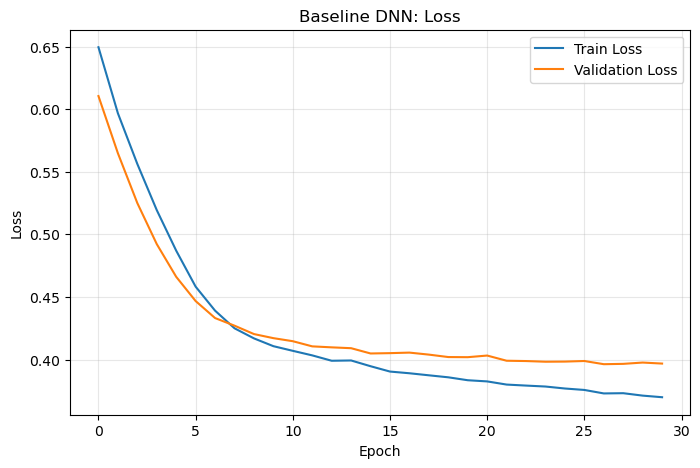

In [93]:
# График Loss
plt.figure(figsize=(8, 5))

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline DNN: Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

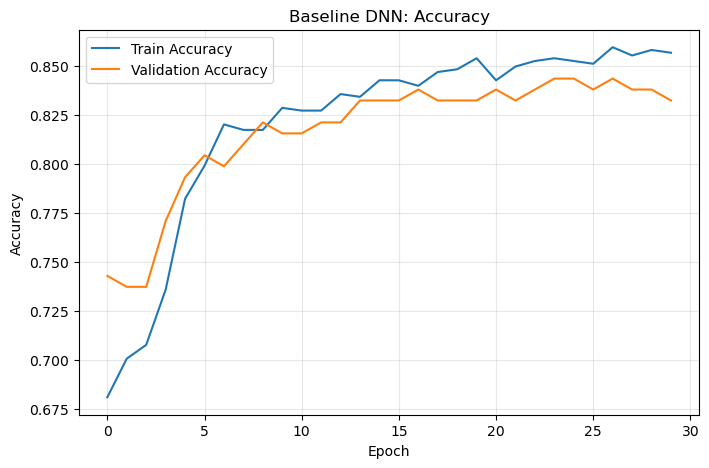

In [94]:
# График Accuracy
plt.figure(figsize=(8, 5))

plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline DNN: Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Вывод по базовой модели

Базовая DNN показала стабильное обучение: значения `loss` постепенно снижались как на обучающей, так и на валидационной выборке.

Validation Accuracy достигла примерно **84%**. После 15–20 эпох рост качества на validation практически остановился, в то время как качество на train продолжило немного улучшаться.

Выраженного переобучения не наблюдается, однако небольшое расхождение между train и validation начинает появляться.

Полученный результат будем использовать как baseline для сравнения с более сложными архитектурами.

### 8.3 Увеличение глубины нейронной сети

Попробуем увеличить количество скрытых слоев модели.

Добавим второй скрытый слой и постепенно уменьшим количество нейронов: `64 → 32`. Между линейными слоями будем использовать функцию активации `ReLU`.

Сравним результат более глубокой сети с базовой моделью.

In [95]:
# DNN с двумя скрытыми слоями
class TitanicDNNDeep(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)

        return x


# Создадим более глубокую модель
model_deep = TitanicDNNDeep(input_size)

print(model_deep)

TitanicDNNDeep(
  (fc1): Linear(in_features=42, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


#### Обучение более глубокой модели

Обучим модель с двумя скрытыми слоями в тех же условиях, что и базовую модель.

Оставим без изменений функцию потерь, оптимизатор, `learning_rate`, `batch_size` и количество эпох. Таким образом, основным изменением будет глубина и размер скрытых слоев сети.

In [96]:
# Создадим оптимизатор для новой модели
optimizer_deep = torch.optim.Adam(
    model_deep.parameters(),
    lr=LEARNING_RATE
)

# Обучим модель
train_loss_deep, train_acc_deep, val_loss_deep, val_acc_deep = train_model(
    model=model_deep,
    train_loader=train_loader,
    valid_loader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_deep,
    epochs=EPOCHS
)

Epoch [1/30] Train Loss: 0.6578 | Train Acc: 0.6334 | Val Loss: 0.6188 | Val Acc: 0.7263
Epoch [2/30] Train Loss: 0.5801 | Train Acc: 0.7037 | Val Loss: 0.5227 | Val Acc: 0.7318
Epoch [3/30] Train Loss: 0.4941 | Train Acc: 0.7570 | Val Loss: 0.4493 | Val Acc: 0.7933
Epoch [4/30] Train Loss: 0.4347 | Train Acc: 0.8174 | Val Loss: 0.4211 | Val Acc: 0.8212
Epoch [5/30] Train Loss: 0.4139 | Train Acc: 0.8244 | Val Loss: 0.4147 | Val Acc: 0.8156
Epoch [6/30] Train Loss: 0.4084 | Train Acc: 0.8230 | Val Loss: 0.4077 | Val Acc: 0.8268
Epoch [7/30] Train Loss: 0.3988 | Train Acc: 0.8343 | Val Loss: 0.4076 | Val Acc: 0.8268
Epoch [8/30] Train Loss: 0.3901 | Train Acc: 0.8483 | Val Loss: 0.4026 | Val Acc: 0.8212
Epoch [9/30] Train Loss: 0.3831 | Train Acc: 0.8469 | Val Loss: 0.4048 | Val Acc: 0.8324
Epoch [10/30] Train Loss: 0.3790 | Train Acc: 0.8525 | Val Loss: 0.4006 | Val Acc: 0.8324
Epoch [11/30] Train Loss: 0.3741 | Train Acc: 0.8497 | Val Loss: 0.3998 | Val Acc: 0.8268
Epoch [12/30] Train

#### Сравнение Baseline и Deep DNN

Сравним процесс обучения базовой и более глубокой моделей.

Особое внимание уделим поведению `validation loss`: его рост при продолжающемся снижении `train loss` может указывать на переобучение модели.

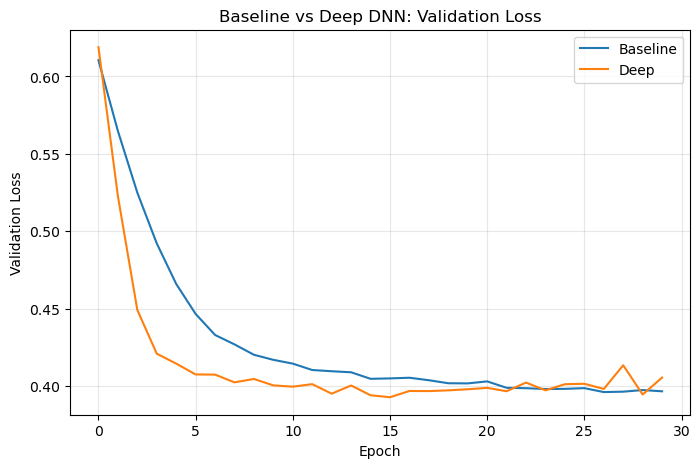

In [97]:
# Сравним Validation Loss моделей
plt.figure(figsize=(8, 5))

plt.plot(val_loss, label="Baseline")
plt.plot(val_loss_deep, label="Deep")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Baseline vs Deep DNN: Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

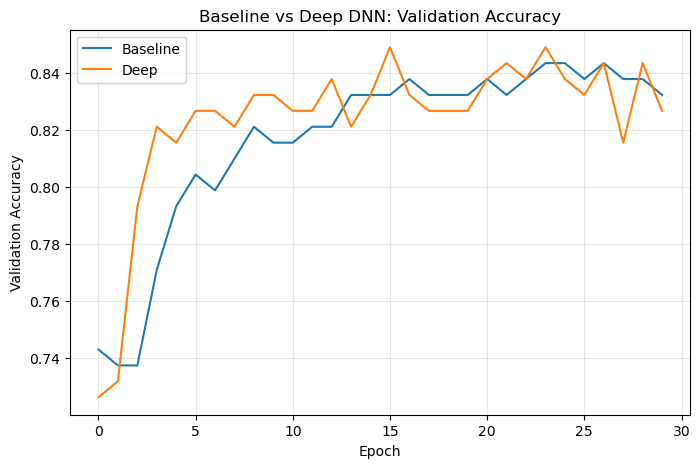

In [98]:
# Сравним Validation Accuracy моделей
plt.figure(figsize=(8, 5))

plt.plot(val_acc, label="Baseline")
plt.plot(val_acc_deep, label="Deep")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs Deep DNN: Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [99]:
print(f"Baseline best Val Accuracy: {max(val_acc):.4f}")
print(f"Deep best Val Accuracy:     {max(val_acc_deep):.4f}")

print(f"Baseline final Val Loss:    {val_loss[-1]:.4f}")
print(f"Deep final Val Loss:        {val_loss_deep[-1]:.4f}")

Baseline best Val Accuracy: 0.8436
Deep best Val Accuracy:     0.8492
Baseline final Val Loss:    0.3968
Deep final Val Loss:        0.4057


#### Вывод

Увеличение глубины сети позволило немного улучшить качество модели.

Максимальная Validation Accuracy увеличилась с **0.8436** у базовой DNN до **0.8492** у Deep DNN.

При этом к концу обучения Validation Loss у более глубокой модели составил **0.4057** против **0.3968** у базовой модели. На поздних эпохах Validation Loss начинает колебаться и увеличиваться, в то время как Train Loss продолжает снижаться.

Это указывает на начало переобучения. Далее попробуем добавить Batch Normalization и оценим её влияние.

### 8.4 Добавление Batch Normalization

Добавим `BatchNorm1d` после линейных слоев более глубокой модели.

Batch Normalization нормализует значения внутри батча перед передачей в функцию активации. Это может сделать обучение более стабильным и улучшить прохождение градиентов через сеть.

Остальные параметры модели и обучения пока оставим без изменений.

In [100]:
# DNN с Batch Normalization
class TitanicDNNBatchNorm(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.fc3(x)

        return x


# Создадим модель
model_bn = TitanicDNNBatchNorm(input_size)

print(model_bn)

TitanicDNNBatchNorm(
  (fc1): Linear(in_features=42, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


#### Обучение модели с Batch Normalization

Обучим модель с Batch Normalization в тех же условиях, что и предыдущую Deep DNN.

Это позволит оценить влияние Batch Normalization отдельно от других изменений архитектуры и параметров обучения.

In [101]:
# Создадим оптимизатор для модели с Batch Normalization
optimizer_bn = torch.optim.Adam(
    model_bn.parameters(),
    lr=LEARNING_RATE
)

# Обучим модель
train_loss_bn, train_acc_bn, val_loss_bn, val_acc_bn = train_model(
    model=model_bn,
    train_loader=train_loader,
    valid_loader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_bn,
    epochs=EPOCHS
)

Epoch [1/30] Train Loss: 0.5814 | Train Acc: 0.7275 | Val Loss: 0.5488 | Val Acc: 0.7933
Epoch [2/30] Train Loss: 0.4678 | Train Acc: 0.8062 | Val Loss: 0.4445 | Val Acc: 0.7989
Epoch [3/30] Train Loss: 0.4270 | Train Acc: 0.8272 | Val Loss: 0.4169 | Val Acc: 0.7933
Epoch [4/30] Train Loss: 0.4054 | Train Acc: 0.8427 | Val Loss: 0.4092 | Val Acc: 0.8156
Epoch [5/30] Train Loss: 0.3899 | Train Acc: 0.8399 | Val Loss: 0.4005 | Val Acc: 0.8324
Epoch [6/30] Train Loss: 0.3848 | Train Acc: 0.8525 | Val Loss: 0.3897 | Val Acc: 0.8212
Epoch [7/30] Train Loss: 0.3577 | Train Acc: 0.8736 | Val Loss: 0.3936 | Val Acc: 0.8436
Epoch [8/30] Train Loss: 0.3614 | Train Acc: 0.8596 | Val Loss: 0.3889 | Val Acc: 0.8436
Epoch [9/30] Train Loss: 0.3471 | Train Acc: 0.8708 | Val Loss: 0.3909 | Val Acc: 0.8380
Epoch [10/30] Train Loss: 0.3375 | Train Acc: 0.8680 | Val Loss: 0.3893 | Val Acc: 0.8492
Epoch [11/30] Train Loss: 0.3250 | Train Acc: 0.8848 | Val Loss: 0.4076 | Val Acc: 0.8212
Epoch [12/30] Train

#### Сравнение модели с Batch Normalization

Сравним модель с Batch Normalization с предыдущей Deep DNN.

Оценим изменение `validation loss` и `validation accuracy`, чтобы определить, помогла ли нормализация сделать обучение более стабильным и улучшить обобщающую способность модели.

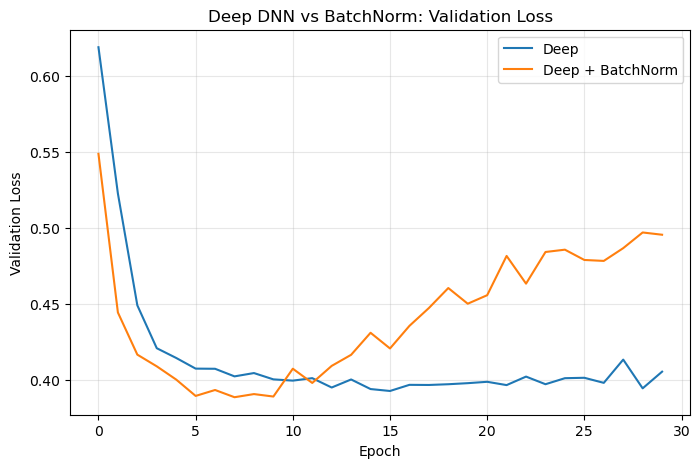

In [102]:
# Сравним Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(val_loss_deep, label="Deep")
plt.plot(val_loss_bn, label="Deep + BatchNorm")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Deep DNN vs BatchNorm: Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

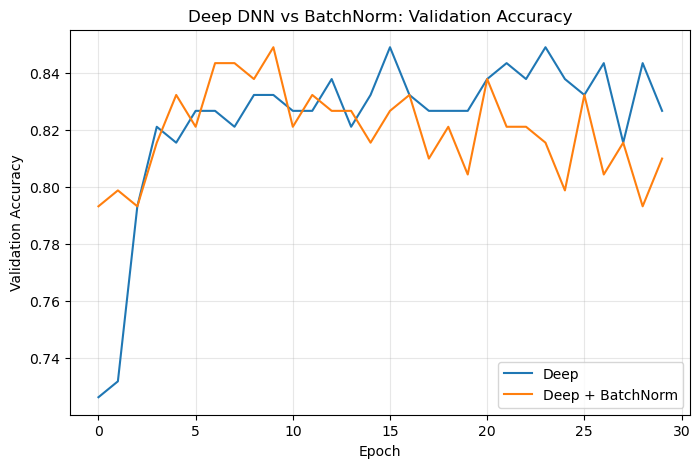

In [103]:
# Сравним Validation Accuracy
plt.figure(figsize=(8, 5))

plt.plot(val_acc_deep, label="Deep")
plt.plot(val_acc_bn, label="Deep + BatchNorm")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Deep DNN vs BatchNorm: Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [104]:
print(f"Deep best Val Accuracy:      {max(val_acc_deep):.4f}")
print(f"BatchNorm best Val Accuracy: {max(val_acc_bn):.4f}")

print(f"Deep min Val Loss:           {min(val_loss_deep):.4f}")
print(f"BatchNorm min Val Loss:      {min(val_loss_bn):.4f}")

Deep best Val Accuracy:      0.8492
BatchNorm best Val Accuracy: 0.8492
Deep min Val Loss:           0.3930
BatchNorm min Val Loss:      0.3889


#### Вывод

Добавление Batch Normalization не улучшило максимальную Validation Accuracy: как Deep DNN, так и модель с Batch Normalization показали **0.8492**.

При этом минимальный Validation Loss уменьшился с **0.3930** до **0.3889**.

На поздних эпохах Validation Loss начинает увеличиваться, в то время как ошибка на обучающей выборке продолжает снижаться, что указывает на переобучение.

Таким образом, Batch Normalization немного улучшила минимальный Validation Loss, но преимущества по Accuracy не дала.

### 8.5 Добавление Dropout

Попробуем уменьшить переобучение с помощью `Dropout`.

Во время обучения Dropout случайным образом отключает часть нейронов, что мешает модели слишком сильно зависеть от отдельных признаков и может улучшить её способность к обобщению.

Проверим несколько значений вероятности отключения нейронов и сравним результаты.

In [105]:
# DNN с Dropout
class TitanicDNNDropout(nn.Module):

    def __init__(self, input_size, dropout_rate=0.2):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

#### Эксперимент с разными значениями Dropout

Проверим несколько значений `dropout_rate`: `0.1`, `0.3` и `0.5`.

Для каждого значения создадим новую модель и обучим её с одинаковыми параметрами. Это позволит оценить, какая степень регуляризации лучше подходит для нашей модели.

In [106]:
# Значения Dropout для эксперимента
dropout_rates = [0.1, 0.3, 0.5]

# Сохраним результаты обучения
dropout_results = {}

for dropout_rate in dropout_rates:

    print(f"\nDropout = {dropout_rate}")
    print("-" * 50)

    # Создадим новую модель
    model_dropout = TitanicDNNDropout(
        input_size,
        dropout_rate=dropout_rate
    )

    # Для каждой модели нужен свой optimizer
    optimizer_dropout = torch.optim.Adam(
        model_dropout.parameters(),
        lr=LEARNING_RATE
    )

    # Обучим модель
    history = train_model(
        model=model_dropout,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=optimizer_dropout,
        epochs=EPOCHS
    )

    # Сохраним историю обучения
    dropout_results[dropout_rate] = history


Dropout = 0.1
--------------------------------------------------
Epoch [1/30] Train Loss: 0.6776 | Train Acc: 0.6011 | Val Loss: 0.6378 | Val Acc: 0.7263
Epoch [2/30] Train Loss: 0.6058 | Train Acc: 0.6966 | Val Loss: 0.5500 | Val Acc: 0.7486
Epoch [3/30] Train Loss: 0.5198 | Train Acc: 0.7374 | Val Loss: 0.4683 | Val Acc: 0.8156
Epoch [4/30] Train Loss: 0.4582 | Train Acc: 0.8034 | Val Loss: 0.4349 | Val Acc: 0.8101
Epoch [5/30] Train Loss: 0.4306 | Train Acc: 0.8062 | Val Loss: 0.4210 | Val Acc: 0.8212
Epoch [6/30] Train Loss: 0.4150 | Train Acc: 0.8301 | Val Loss: 0.4112 | Val Acc: 0.8101
Epoch [7/30] Train Loss: 0.4042 | Train Acc: 0.8287 | Val Loss: 0.4072 | Val Acc: 0.8268
Epoch [8/30] Train Loss: 0.4009 | Train Acc: 0.8427 | Val Loss: 0.4052 | Val Acc: 0.8324
Epoch [9/30] Train Loss: 0.3941 | Train Acc: 0.8441 | Val Loss: 0.4069 | Val Acc: 0.8380
Epoch [10/30] Train Loss: 0.3953 | Train Acc: 0.8441 | Val Loss: 0.4055 | Val Acc: 0.8492
Epoch [11/30] Train Loss: 0.3894 | Train Ac

#### Сравнение результатов Dropout

Сравним максимальную Validation Accuracy и минимальный Validation Loss для каждого значения `dropout_rate`.

Это позволит оценить влияние силы регуляризации на качество модели.

In [107]:
# Сравним результаты для разных значений Dropout
for dropout_rate, history in dropout_results.items():

    train_loss_drop, train_acc_drop, val_loss_drop, val_acc_drop = history

    print(
        f"Dropout = {dropout_rate} | "
        f"Best Val Accuracy: {max(val_acc_drop):.4f} | "
        f"Min Val Loss: {min(val_loss_drop):.4f}"
    )

Dropout = 0.1 | Best Val Accuracy: 0.8492 | Min Val Loss: 0.3931
Dropout = 0.3 | Best Val Accuracy: 0.8492 | Min Val Loss: 0.3863
Dropout = 0.5 | Best Val Accuracy: 0.8547 | Min Val Loss: 0.3937


#### Графики обучения моделей с Dropout

Сравним изменение Validation Loss и Validation Accuracy для разных значений `dropout_rate`.

Это позволит оценить не только лучший достигнутый результат, но и стабильность обучения моделей.

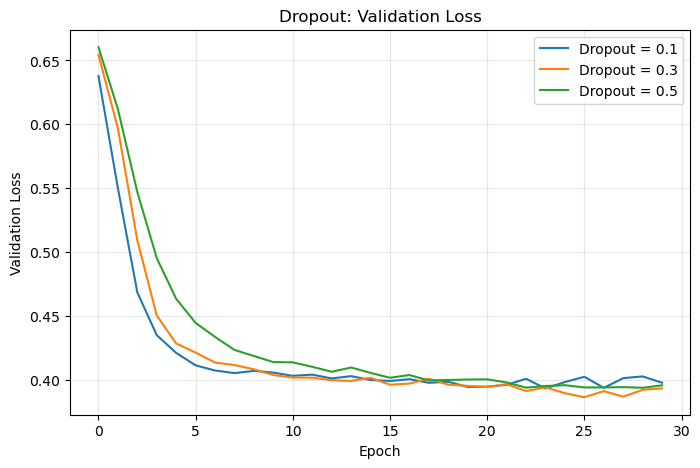

In [108]:
plt.figure(figsize=(8, 5))

for dropout_rate, history in dropout_results.items():

    _, _, val_loss_drop, _ = history

    plt.plot(
        val_loss_drop,
        label=f"Dropout = {dropout_rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Dropout: Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

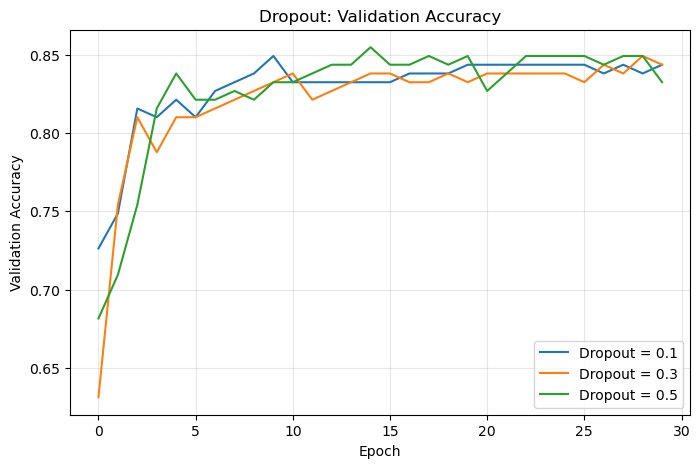

In [109]:
plt.figure(figsize=(8, 5))

for dropout_rate, history in dropout_results.items():

    _, _, _, val_acc_drop = history

    plt.plot(
        val_acc_drop,
        label=f"Dropout = {dropout_rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Dropout: Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Вывод

Добавление Dropout позволило получить близкие результаты при разных значениях коэффициента регуляризации.

Наибольшую Validation Accuracy показал `Dropout = 0.5` — **0.8547**.

При этом минимальный Validation Loss был получен при `Dropout = 0.3` — **0.3863**.

Для дальнейших экспериментов будем использовать `dropout_rate = 0.3`: при близком качестве по Accuracy этот вариант показал наименьший Validation Loss.

### 8.6 Размеры скрытых слоев и функции активации

Попробуем изменить количество нейронов в скрытых слоях модели.

Сначала сравним несколько размеров скрытых слоев, сохранив `ReLU` и `Dropout = 0.3`. После выбора подходящей архитектуры отдельно сравним несколько функций активации.

Такой подход позволит оценить влияние каждого изменения отдельно.

In [110]:
# DNN с настраиваемыми размерами скрытых слоев
class TitanicDNNCustom(nn.Module):

    def __init__(self, input_size, hidden_size1, hidden_size2, dropout_rate=0.3):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(hidden_size2, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

#### Эксперимент с размерами скрытых слоев

Сравним три варианта размеров скрытых слоев: `32 → 16`, `64 → 32` и `128 → 64`.

Остальные параметры модели и обучения оставим без изменений, чтобы оценить влияние размера скрытых слоев на качество модели.

In [111]:
# Варианты размеров скрытых слоев
hidden_sizes = [
    (32, 16),
    (64, 32),
    (128, 64)
]

# Сохраним результаты эксперимента
hidden_size_results = {}

for hidden_size1, hidden_size2 in hidden_sizes:

    print(f"\nHidden layers: {hidden_size1} → {hidden_size2}")
    print("-" * 50)

    # Создадим модель
    model_custom = TitanicDNNCustom(
        input_size=input_size,
        hidden_size1=hidden_size1,
        hidden_size2=hidden_size2,
        dropout_rate=0.3
    )

    # Создадим optimizer для новой модели
    optimizer_custom = torch.optim.Adam(
        model_custom.parameters(),
        lr=LEARNING_RATE
    )

    # Обучим модель
    history = train_model(
        model=model_custom,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=optimizer_custom,
        epochs=EPOCHS
    )

    # Сохраним историю обучения
    hidden_size_results[(hidden_size1, hidden_size2)] = history


Hidden layers: 32 → 16
--------------------------------------------------
Epoch [1/30] Train Loss: 0.6734 | Train Acc: 0.6278 | Val Loss: 0.6606 | Val Acc: 0.6369
Epoch [2/30] Train Loss: 0.6545 | Train Acc: 0.6292 | Val Loss: 0.6355 | Val Acc: 0.6760
Epoch [3/30] Train Loss: 0.6278 | Train Acc: 0.6643 | Val Loss: 0.5997 | Val Acc: 0.7374
Epoch [4/30] Train Loss: 0.5908 | Train Acc: 0.6924 | Val Loss: 0.5526 | Val Acc: 0.7542
Epoch [5/30] Train Loss: 0.5621 | Train Acc: 0.7360 | Val Loss: 0.5073 | Val Acc: 0.7989
Epoch [6/30] Train Loss: 0.5285 | Train Acc: 0.7640 | Val Loss: 0.4716 | Val Acc: 0.7989
Epoch [7/30] Train Loss: 0.4876 | Train Acc: 0.7963 | Val Loss: 0.4469 | Val Acc: 0.8101
Epoch [8/30] Train Loss: 0.4692 | Train Acc: 0.8090 | Val Loss: 0.4323 | Val Acc: 0.7989
Epoch [9/30] Train Loss: 0.4728 | Train Acc: 0.8146 | Val Loss: 0.4246 | Val Acc: 0.8156
Epoch [10/30] Train Loss: 0.4582 | Train Acc: 0.8104 | Val Loss: 0.4188 | Val Acc: 0.8212
Epoch [11/30] Train Loss: 0.4315 |

In [112]:
# Сравним результаты разных размеров скрытых слоев
for hidden_sizes, history in hidden_size_results.items():

    _, _, val_loss_custom, val_acc_custom = history

    print(
        f"Hidden layers: {hidden_sizes[0]} → {hidden_sizes[1]} | "
        f"Best Val Accuracy: {max(val_acc_custom):.4f} | "
        f"Min Val Loss: {min(val_loss_custom):.4f}"
    )

Hidden layers: 32 → 16 | Best Val Accuracy: 0.8436 | Min Val Loss: 0.3932
Hidden layers: 64 → 32 | Best Val Accuracy: 0.8547 | Min Val Loss: 0.3916
Hidden layers: 128 → 64 | Best Val Accuracy: 0.8492 | Min Val Loss: 0.3842


#### Вывод

Изменение размеров скрытых слоев дало близкие результаты.

Наибольшую Validation Accuracy — **0.8547** — показала архитектура `64 → 32`.

Архитектура `128 → 64` показала Accuracy **0.8492**, но при этом достигла минимального Validation Loss — **0.3842**.

Архитектура `32 → 16` показала Accuracy **0.8436** и остается значительно более компактной. Для дальнейшего сравнения функций активации будем использовать архитектуру `32 → 16`, не усложняя модель.

#### Эксперимент с функциями активации

Проверим влияние разных функций активации на качество модели.

Сравним `ReLU`, `LeakyReLU` и `GELU`, сохранив одинаковую архитектуру `32 → 16`, `Dropout = 0.3` и остальные параметры обучения.

In [113]:
# DNN с настраиваемой функцией активации
class TitanicDNNActivation(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size1,
        hidden_size2,
        activation,
        dropout_rate=0.3
    ):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.activation1 = activation()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.activation2 = activation()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(hidden_size2, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.activation2(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

In [114]:
# Функции активации для эксперимента
activations = {
    "ReLU": nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "GELU": nn.GELU
}

# Сохраним результаты обучения
activation_results = {}

for activation_name, activation in activations.items():

    print(f"\nActivation: {activation_name}")
    print("-" * 50)

    # Создадим модель
    model_activation = TitanicDNNActivation(
        input_size=input_size,
        hidden_size1=32,
        hidden_size2=16,
        activation=activation,
        dropout_rate=0.3
    )

    # Создадим optimizer
    optimizer_activation = torch.optim.Adam(
        model_activation.parameters(),
        lr=LEARNING_RATE
    )

    # Обучим модель
    history = train_model(
        model=model_activation,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=optimizer_activation,
        epochs=EPOCHS
    )

    # Сохраним историю обучения
    activation_results[activation_name] = history


Activation: ReLU
--------------------------------------------------
Epoch [1/30] Train Loss: 0.6684 | Train Acc: 0.6166 | Val Loss: 0.6596 | Val Acc: 0.6145
Epoch [2/30] Train Loss: 0.6560 | Train Acc: 0.6166 | Val Loss: 0.6407 | Val Acc: 0.6145
Epoch [3/30] Train Loss: 0.6296 | Train Acc: 0.6264 | Val Loss: 0.6053 | Val Acc: 0.6704
Epoch [4/30] Train Loss: 0.5978 | Train Acc: 0.6671 | Val Loss: 0.5588 | Val Acc: 0.7542
Epoch [5/30] Train Loss: 0.5411 | Train Acc: 0.7528 | Val Loss: 0.5019 | Val Acc: 0.8101
Epoch [6/30] Train Loss: 0.5161 | Train Acc: 0.7767 | Val Loss: 0.4615 | Val Acc: 0.8045
Epoch [7/30] Train Loss: 0.4772 | Train Acc: 0.7907 | Val Loss: 0.4371 | Val Acc: 0.8045
Epoch [8/30] Train Loss: 0.4566 | Train Acc: 0.8034 | Val Loss: 0.4248 | Val Acc: 0.8156
Epoch [9/30] Train Loss: 0.4492 | Train Acc: 0.8104 | Val Loss: 0.4197 | Val Acc: 0.8156
Epoch [10/30] Train Loss: 0.4334 | Train Acc: 0.8230 | Val Loss: 0.4145 | Val Acc: 0.8268
Epoch [11/30] Train Loss: 0.4335 | Train

In [115]:
# Сравним результаты разных функций активации
for activation_name, history in activation_results.items():

    _, _, val_loss_activation, val_acc_activation = history

    print(
        f"{activation_name:10} | "
        f"Best Val Accuracy: {max(val_acc_activation):.4f} | "
        f"Min Val Loss: {min(val_loss_activation):.4f}"
    )

ReLU       | Best Val Accuracy: 0.8547 | Min Val Loss: 0.3858
LeakyReLU  | Best Val Accuracy: 0.8436 | Min Val Loss: 0.3966
GELU       | Best Val Accuracy: 0.8436 | Min Val Loss: 0.3934


#### Вывод

В данном запуске лучший результат показала функция активации `ReLU`.

Максимальная Validation Accuracy составила **0.8547**, а минимальный Validation Loss — **0.3858**.

`LeakyReLU` и `GELU` показали одинаковую максимальную Accuracy — **0.8436**.

Результаты отдельных запусков DNN зависят от случайной инициализации весов и порядка формирования batch. Для следующих экспериментов сохраним ранее выбранный `LeakyReLU`, чтобы не менять остальные параметры одновременно.

### 8.7 Сравнение оптимизаторов

Сравним несколько оптимизаторов при одинаковой архитектуре и параметрах обучения.

Используем архитектуру `32 → 16`, `LeakyReLU` и `Dropout = 0.3`. Проверим оптимизаторы `Adam`, `AdamW` и `SGD`.

Для каждого оптимизатора создадим новую модель, чтобы обучение начиналось с нуля.

In [116]:
# Оптимизаторы для эксперимента
optimizers = {
    "Adam": lambda params: torch.optim.Adam(
        params,
        lr=LEARNING_RATE
    ),

    "AdamW": lambda params: torch.optim.AdamW(
        params,
        lr=LEARNING_RATE
    ),

    "SGD": lambda params: torch.optim.SGD(
        params,
        lr=LEARNING_RATE,
        momentum=0.9
    )
}

# Сохраним результаты обучения
optimizer_results = {}

for optimizer_name, optimizer_fn in optimizers.items():

    print(f"\nOptimizer: {optimizer_name}")
    print("-" * 50)

    # Создадим новую модель
    model_optimizer = TitanicDNNActivation(
        input_size=input_size,
        hidden_size1=32,
        hidden_size2=16,
        activation=nn.LeakyReLU,
        dropout_rate=0.3
    )

    # Создадим выбранный optimizer
    optimizer_test = optimizer_fn(
        model_optimizer.parameters()
    )

    # Обучим модель
    history = train_model(
        model=model_optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=optimizer_test,
        epochs=EPOCHS
    )

    optimizer_results[optimizer_name] = history


Optimizer: Adam
--------------------------------------------------
Epoch [1/30] Train Loss: 0.6666 | Train Acc: 0.6180 | Val Loss: 0.6562 | Val Acc: 0.6145
Epoch [2/30] Train Loss: 0.6448 | Train Acc: 0.6166 | Val Loss: 0.6276 | Val Acc: 0.6145
Epoch [3/30] Train Loss: 0.6163 | Train Acc: 0.6320 | Val Loss: 0.5908 | Val Acc: 0.6313
Epoch [4/30] Train Loss: 0.5831 | Train Acc: 0.6826 | Val Loss: 0.5486 | Val Acc: 0.7598
Epoch [5/30] Train Loss: 0.5395 | Train Acc: 0.7331 | Val Loss: 0.4989 | Val Acc: 0.7989
Epoch [6/30] Train Loss: 0.4991 | Train Acc: 0.7781 | Val Loss: 0.4631 | Val Acc: 0.7989
Epoch [7/30] Train Loss: 0.4676 | Train Acc: 0.8034 | Val Loss: 0.4375 | Val Acc: 0.8101
Epoch [8/30] Train Loss: 0.4547 | Train Acc: 0.8090 | Val Loss: 0.4275 | Val Acc: 0.8101
Epoch [9/30] Train Loss: 0.4491 | Train Acc: 0.8104 | Val Loss: 0.4206 | Val Acc: 0.8156
Epoch [10/30] Train Loss: 0.4350 | Train Acc: 0.8230 | Val Loss: 0.4173 | Val Acc: 0.8156
Epoch [11/30] Train Loss: 0.4137 | Train 

In [117]:
# Сравним результаты оптимизаторов
for optimizer_name, history in optimizer_results.items():

    _, _, val_loss_optimizer, val_acc_optimizer = history

    print(
        f"{optimizer_name:5} | "
        f"Best Val Accuracy: {max(val_acc_optimizer):.4f} | "
        f"Min Val Loss: {min(val_loss_optimizer):.4f}"
    )

Adam  | Best Val Accuracy: 0.8492 | Min Val Loss: 0.3943
AdamW | Best Val Accuracy: 0.8492 | Min Val Loss: 0.3897
SGD   | Best Val Accuracy: 0.7039 | Min Val Loss: 0.5778


#### Вывод

Оптимизаторы `Adam` и `AdamW` показали одинаковую максимальную Validation Accuracy — **0.8492**.

При этом `AdamW` достиг немного меньшего Validation Loss: **0.3897** против **0.3943** у Adam.

`SGD` с `learning_rate = 0.001` обучался значительно медленнее и показал Validation Accuracy **0.7039**.

Для дальнейших экспериментов сохраним `Adam`, который показывает сопоставимое качество и используется в основной конфигурации модели.

### 8.8 Learning Rate, Scheduler

Добавим scheduler `ReduceLROnPlateau`, который будет уменьшать `learning_rate`, если Validation Loss перестает улучшаться.

В отличие от фиксированного learning rate, такой подход позволяет использовать больший шаг в начале обучения и уменьшать его, когда модель приближается к минимуму функции потерь.

In [118]:
def train_model(
    model,
    train_loader,
    valid_loader,
    loss_fn,
    optimizer,
    epochs,
    scheduler=None
):
    # История обучения
    train_loss = []
    train_acc = []

    val_loss = []
    val_acc = []

    for epoch in range(epochs):

        # --------------------
        # Обучение
        # --------------------

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

            predictions = (torch.sigmoid(logits) >= 0.5).float()

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        train_loss.append(epoch_train_loss)
        train_acc.append(epoch_train_acc)

        # --------------------
        # Валидация
        # --------------------

        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                logits = model(X_batch)
                loss = loss_fn(logits, y_batch)

                running_loss += loss.item() * X_batch.size(0)

                predictions = (torch.sigmoid(logits) >= 0.5).float()

                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        epoch_val_loss = running_loss / total
        epoch_val_acc = correct / total

        val_loss.append(epoch_val_loss)
        val_acc.append(epoch_val_acc)

        # Обновим learning rate
        if scheduler is not None:
            scheduler.step(epoch_val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_acc:.4f} | "
            f"LR: {current_lr:.6f}"
        )

    return train_loss, train_acc, val_loss, val_acc

In [119]:
# Создадим модель
model_scheduler = TitanicDNNActivation(
    input_size=input_size,
    hidden_size1=32,
    hidden_size2=16,
    activation=nn.LeakyReLU,
    dropout_rate=0.3
)

# Optimizer
optimizer_scheduler = torch.optim.Adam(
    model_scheduler.parameters(),
    lr=LEARNING_RATE
)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_scheduler,
    mode="min",
    factor=0.5,
    patience=3
)

In [120]:
EPOCHS_SCHEDULER = 50

train_loss_scheduler, train_acc_scheduler, \
val_loss_scheduler, val_acc_scheduler = train_model(
    model=model_scheduler,
    train_loader=train_loader,
    valid_loader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer_scheduler,
    epochs=EPOCHS_SCHEDULER,
    scheduler=scheduler
)

Epoch [1/50] Train Loss: 0.6673 | Train Acc: 0.6194 | Val Loss: 0.6579 | Val Acc: 0.6145 | LR: 0.001000
Epoch [2/50] Train Loss: 0.6444 | Train Acc: 0.6320 | Val Loss: 0.6234 | Val Acc: 0.6145 | LR: 0.001000
Epoch [3/50] Train Loss: 0.6100 | Train Acc: 0.6503 | Val Loss: 0.5679 | Val Acc: 0.7430 | LR: 0.001000
Epoch [4/50] Train Loss: 0.5605 | Train Acc: 0.6966 | Val Loss: 0.5122 | Val Acc: 0.7542 | LR: 0.001000
Epoch [5/50] Train Loss: 0.5213 | Train Acc: 0.7346 | Val Loss: 0.4772 | Val Acc: 0.7933 | LR: 0.001000
Epoch [6/50] Train Loss: 0.5006 | Train Acc: 0.7739 | Val Loss: 0.4581 | Val Acc: 0.7877 | LR: 0.001000
Epoch [7/50] Train Loss: 0.4694 | Train Acc: 0.7921 | Val Loss: 0.4385 | Val Acc: 0.8101 | LR: 0.001000
Epoch [8/50] Train Loss: 0.4557 | Train Acc: 0.8062 | Val Loss: 0.4277 | Val Acc: 0.8045 | LR: 0.001000
Epoch [9/50] Train Loss: 0.4429 | Train Acc: 0.8202 | Val Loss: 0.4188 | Val Acc: 0.8101 | LR: 0.001000
Epoch [10/50] Train Loss: 0.4240 | Train Acc: 0.8188 | Val Loss:

In [121]:
print(f"Best Val Accuracy: {max(val_acc_scheduler):.4f}")
print(f"Min Val Loss: {min(val_loss_scheduler):.4f}")

Best Val Accuracy: 0.8492
Min Val Loss: 0.3934


#### Вывод

Scheduler `ReduceLROnPlateau` начал уменьшать learning rate после того, как Validation Loss перестал улучшаться.

Learning rate был уменьшен с `0.001` до `0.0005`, а затем до `0.00025`.

Минимальный Validation Loss составил **0.3934**, а максимальная Validation Accuracy — **0.8492**.

Добавление scheduler не привело к заметному улучшению Accuracy, однако позволило автоматически уменьшать шаг обучения при выходе модели на плато.

### 8.9 Настройка параметров обучения

Попробуем изменить основные параметры процесса обучения: `learning rate`, `batch size` и количество эпох.

Сначала исследуем влияние `learning rate`, оставив остальные параметры модели без изменений.

In [122]:
# Значения learning rate для эксперимента
learning_rates = [0.0001, 0.001, 0.01]

# Сохраним результаты обучения
lr_results = {}

for lr in learning_rates:

    print(f"\nLearning Rate: {lr}")
    print("-" * 50)

    # Создадим новую модель
    model_lr = TitanicDNNActivation(
        input_size=input_size,
        hidden_size1=32,
        hidden_size2=16,
        activation=nn.LeakyReLU,
        dropout_rate=0.3
    )

    # Создадим optimizer с выбранным learning rate
    optimizer_lr = torch.optim.Adam(
        model_lr.parameters(),
        lr=lr
    )

    # Обучим модель
    history = train_model(
        model=model_lr,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=optimizer_lr,
        epochs=EPOCHS
    )

    # Сохраним историю обучения
    lr_results[lr] = history


Learning Rate: 0.0001
--------------------------------------------------
Epoch [1/30] Train Loss: 0.6865 | Train Acc: 0.6138 | Val Loss: 0.6840 | Val Acc: 0.6369 | LR: 0.000100
Epoch [2/30] Train Loss: 0.6822 | Train Acc: 0.6503 | Val Loss: 0.6821 | Val Acc: 0.6425 | LR: 0.000100
Epoch [3/30] Train Loss: 0.6812 | Train Acc: 0.6433 | Val Loss: 0.6804 | Val Acc: 0.6425 | LR: 0.000100
Epoch [4/30] Train Loss: 0.6812 | Train Acc: 0.6419 | Val Loss: 0.6786 | Val Acc: 0.6480 | LR: 0.000100
Epoch [5/30] Train Loss: 0.6791 | Train Acc: 0.6390 | Val Loss: 0.6767 | Val Acc: 0.6592 | LR: 0.000100
Epoch [6/30] Train Loss: 0.6758 | Train Acc: 0.6643 | Val Loss: 0.6746 | Val Acc: 0.6760 | LR: 0.000100
Epoch [7/30] Train Loss: 0.6743 | Train Acc: 0.6559 | Val Loss: 0.6723 | Val Acc: 0.6816 | LR: 0.000100
Epoch [8/30] Train Loss: 0.6732 | Train Acc: 0.6784 | Val Loss: 0.6697 | Val Acc: 0.7039 | LR: 0.000100
Epoch [9/30] Train Loss: 0.6693 | Train Acc: 0.6629 | Val Loss: 0.6669 | Val Acc: 0.7151 | LR:

In [123]:
# Сравним результаты разных learning rate
for lr, history in lr_results.items():

    _, _, val_loss_lr, val_acc_lr = history

    print(
        f"LR: {lr:<6} | "
        f"Best Val Accuracy: {max(val_acc_lr):.4f} | "
        f"Min Val Loss: {min(val_loss_lr):.4f}"
    )

LR: 0.0001 | Best Val Accuracy: 0.7486 | Min Val Loss: 0.5462
LR: 0.001  | Best Val Accuracy: 0.8547 | Min Val Loss: 0.3819
LR: 0.01   | Best Val Accuracy: 0.8492 | Min Val Loss: 0.3908


#### Вывод

Значение `learning_rate = 0.0001` оказалось слишком маленьким: за 30 эпох модель показала максимальную Validation Accuracy **0.7486**.

Лучший результат был получен при `learning_rate = 0.001`: Validation Accuracy составила **0.8547**, а минимальный Validation Loss — **0.3819**.

При `learning_rate = 0.01` максимальная Validation Accuracy составила **0.8492**, а минимальный Validation Loss — **0.3908**.

Для дальнейших экспериментов оставим `learning_rate = 0.001`.

#### Эксперимент с Batch Size

Проверим влияние размера batch на обучение модели.

Сравним `batch_size = 16`, `32` и `64`, сохранив одинаковую архитектуру модели и `learning_rate = 0.001`.

In [124]:
# Значения batch size для эксперимента
batch_sizes = [16, 32, 64]

# Сохраним результаты обучения
batch_results = {}

for batch_size in batch_sizes:

    print(f"\nBatch Size: {batch_size}")
    print("-" * 50)

    # Создадим DataLoader с новым batch size
    train_loader_batch = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    valid_loader_batch = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Создадим новую модель
    model_batch = TitanicDNNActivation(
        input_size=input_size,
        hidden_size1=32,
        hidden_size2=16,
        activation=nn.LeakyReLU,
        dropout_rate=0.3
    )

    # Создадим optimizer
    optimizer_batch = torch.optim.Adam(
        model_batch.parameters(),
        lr=0.001
    )

    # Обучим модель
    history = train_model(
        model=model_batch,
        train_loader=train_loader_batch,
        valid_loader=valid_loader_batch,
        loss_fn=loss_fn,
        optimizer=optimizer_batch,
        epochs=EPOCHS
    )

    batch_results[batch_size] = history


Batch Size: 16
--------------------------------------------------
Epoch [1/30] Train Loss: 0.6602 | Train Acc: 0.6222 | Val Loss: 0.6316 | Val Acc: 0.6425 | LR: 0.001000
Epoch [2/30] Train Loss: 0.6156 | Train Acc: 0.6489 | Val Loss: 0.5581 | Val Acc: 0.7654 | LR: 0.001000
Epoch [3/30] Train Loss: 0.5623 | Train Acc: 0.7079 | Val Loss: 0.5023 | Val Acc: 0.7821 | LR: 0.001000
Epoch [4/30] Train Loss: 0.5006 | Train Acc: 0.7542 | Val Loss: 0.4545 | Val Acc: 0.8268 | LR: 0.001000
Epoch [5/30] Train Loss: 0.4770 | Train Acc: 0.7907 | Val Loss: 0.4342 | Val Acc: 0.8045 | LR: 0.001000
Epoch [6/30] Train Loss: 0.4441 | Train Acc: 0.8132 | Val Loss: 0.4215 | Val Acc: 0.8156 | LR: 0.001000
Epoch [7/30] Train Loss: 0.4358 | Train Acc: 0.8315 | Val Loss: 0.4146 | Val Acc: 0.8268 | LR: 0.001000
Epoch [8/30] Train Loss: 0.4391 | Train Acc: 0.8287 | Val Loss: 0.4128 | Val Acc: 0.8268 | LR: 0.001000
Epoch [9/30] Train Loss: 0.4401 | Train Acc: 0.8272 | Val Loss: 0.4094 | Val Acc: 0.8268 | LR: 0.0010

In [125]:
# Сравним результаты разных batch size
for batch_size, history in batch_results.items():

    _, _, val_loss_batch, val_acc_batch = history

    print(
        f"Batch Size: {batch_size:<2} | "
        f"Best Val Accuracy: {max(val_acc_batch):.4f} | "
        f"Min Val Loss: {min(val_loss_batch):.4f}"
    )

Batch Size: 16 | Best Val Accuracy: 0.8603 | Min Val Loss: 0.3816
Batch Size: 32 | Best Val Accuracy: 0.8547 | Min Val Loss: 0.3917
Batch Size: 64 | Best Val Accuracy: 0.8492 | Min Val Loss: 0.4009


#### Вывод

Уменьшение размера batch положительно повлияло на качество модели.

Лучший результат был получен при `batch_size = 16`: Validation Accuracy достигла **0.8603**, а минимальный Validation Loss составил **0.3816**.

При `batch_size = 32` максимальная Accuracy составила **0.8547**, а при `batch_size = 64` — **0.8492**.

Поэтому для дальнейшего обучения будем использовать `batch_size = 16`.

#### Эксперимент с количеством эпох

Проверим, как изменяется качество модели при более длительном обучении.

Обучим выбранную модель в течение 50 эпох и определим эпоху, на которой была получена максимальная Validation Accuracy.

In [126]:
train_loader_best = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

valid_loader_best = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False
)

In [127]:
model_epochs = TitanicDNNActivation(
    input_size=input_size,
    hidden_size1=32,
    hidden_size2=16,
    activation=nn.LeakyReLU,
    dropout_rate=0.3
)

optimizer_epochs = torch.optim.Adam(
    model_epochs.parameters(),
    lr=0.001
)

EPOCHS_LONG = 50

train_loss_epochs, train_acc_epochs, \
val_loss_epochs, val_acc_epochs = train_model(
    model=model_epochs,
    train_loader=train_loader_best,
    valid_loader=valid_loader_best,
    loss_fn=loss_fn,
    optimizer=optimizer_epochs,
    epochs=EPOCHS_LONG
)

Epoch [1/50] Train Loss: 0.6730 | Train Acc: 0.6194 | Val Loss: 0.6607 | Val Acc: 0.6145 | LR: 0.001000
Epoch [2/50] Train Loss: 0.6416 | Train Acc: 0.6348 | Val Loss: 0.5976 | Val Acc: 0.7318 | LR: 0.001000
Epoch [3/50] Train Loss: 0.5643 | Train Acc: 0.7177 | Val Loss: 0.5092 | Val Acc: 0.7989 | LR: 0.001000
Epoch [4/50] Train Loss: 0.4904 | Train Acc: 0.7697 | Val Loss: 0.4586 | Val Acc: 0.7989 | LR: 0.001000
Epoch [5/50] Train Loss: 0.4705 | Train Acc: 0.8048 | Val Loss: 0.4368 | Val Acc: 0.8156 | LR: 0.001000
Epoch [6/50] Train Loss: 0.4542 | Train Acc: 0.8174 | Val Loss: 0.4278 | Val Acc: 0.7989 | LR: 0.001000
Epoch [7/50] Train Loss: 0.4494 | Train Acc: 0.8090 | Val Loss: 0.4273 | Val Acc: 0.8101 | LR: 0.001000
Epoch [8/50] Train Loss: 0.4185 | Train Acc: 0.8525 | Val Loss: 0.4206 | Val Acc: 0.8101 | LR: 0.001000
Epoch [9/50] Train Loss: 0.4324 | Train Acc: 0.8174 | Val Loss: 0.4186 | Val Acc: 0.8268 | LR: 0.001000
Epoch [10/50] Train Loss: 0.4162 | Train Acc: 0.8272 | Val Loss:

In [128]:
best_epoch_acc = val_acc_epochs.index(max(val_acc_epochs)) + 1
best_epoch_loss = val_loss_epochs.index(min(val_loss_epochs)) + 1

print(
    f"Best Val Accuracy: {max(val_acc_epochs):.4f} "
    f"(Epoch {best_epoch_acc})"
)

print(
    f"Min Val Loss: {min(val_loss_epochs):.4f} "
    f"(Epoch {best_epoch_loss})"
)

Best Val Accuracy: 0.8547 (Epoch 31)
Min Val Loss: 0.3944 (Epoch 30)


#### Вывод

При обучении в течение 50 эпох максимальная Validation Accuracy составила **0.8547** и была получена на **31-й эпохе**.

Минимальный Validation Loss — **0.3944** — был получен на **30-й эпохе**.

После этого дальнейшее увеличение количества эпох уже не приводило к устойчивому улучшению качества validation.

Таким образом, для данной модели 50 эпох достаточно, однако увеличение длительности обучения само по себе не гарантирует улучшения результата.

#### Выбор функции потерь

Для задачи бинарной классификации используется `BCEWithLogitsLoss`.

Модель возвращает один `logit`, а `BCEWithLogitsLoss` объединяет применение `Sigmoid` и расчет Binary Cross Entropy в одной численно устойчивой функции.

Поэтому менять функцию потерь в данном случае не будем и оставим `BCEWithLogitsLoss`.

### 8.10 Финальная DNN

На основе проведенных экспериментов соберем финальную нейронную сеть.

Для финальной модели используем:

- два скрытых слоя `32 → 16`;
- функцию активации `LeakyReLU`;
- `Dropout = 0.3`;
- optimizer `Adam`;
- начальный `learning_rate = 0.001`;
- `batch_size = 16`;
- функцию потерь `BCEWithLogitsLoss`;
- scheduler `ReduceLROnPlateau`;
- максимальное количество эпох — `50`.

Во время обучения будем сохранять веса модели с минимальным Validation Loss.

In [129]:
class FinalTitanicDNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 32)
        self.activation1 = nn.LeakyReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(32, 16)
        self.activation2 = nn.LeakyReLU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):

        x = self.fc1(x)
        x = self.activation1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.activation2(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

In [130]:
FINAL_BATCH_SIZE = 16

train_loader_final = DataLoader(
    train_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True
)

valid_loader_final = DataLoader(
    valid_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=False
)

In [131]:
# Создадим финальную модель
final_model = FinalTitanicDNN(input_size)

# Функция потерь
final_loss_fn = nn.BCEWithLogitsLoss()

# Optimizer
final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=0.001
)

# Scheduler
final_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    final_optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

FINAL_EPOCHS = 50

print(final_model)

FinalTitanicDNN(
  (fc1): Linear(in_features=42, out_features=32, bias=True)
  (activation1): LeakyReLU(negative_slope=0.01)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (activation2): LeakyReLU(negative_slope=0.01)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
)


In [132]:
# История обучения
final_train_loss = []
final_train_acc = []

final_val_loss = []
final_val_acc = []

# Лучший результат
best_val_loss = float("inf")
best_epoch = 0
best_model_state = None


for epoch in range(FINAL_EPOCHS):

    # --------------------
    # Обучение
    # --------------------

    final_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader_final:

        final_optimizer.zero_grad()

        logits = final_model(X_batch)
        loss = final_loss_fn(logits, y_batch)

        loss.backward()
        final_optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = (torch.sigmoid(logits) >= 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    final_train_loss.append(epoch_train_loss)
    final_train_acc.append(epoch_train_acc)


    # --------------------
    # Валидация
    # --------------------

    final_model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in valid_loader_final:

            logits = final_model(X_batch)
            loss = final_loss_fn(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            predictions = (torch.sigmoid(logits) >= 0.5).float()

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_val_loss = running_loss / total
    epoch_val_acc = correct / total

    final_val_loss.append(epoch_val_loss)
    final_val_acc.append(epoch_val_acc)


    # --------------------
    # Сохраним лучшие веса
    # --------------------

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            final_model.state_dict()
        )


    # --------------------
    # Scheduler
    # --------------------

    final_scheduler.step(epoch_val_loss)

    current_lr = final_optimizer.param_groups[0]["lr"]


    # --------------------
    # Результаты эпохи
    # --------------------

    print(
        f"Epoch [{epoch + 1}/{FINAL_EPOCHS}] "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )


# Вернем модели лучшие веса
final_model.load_state_dict(best_model_state)

Epoch [1/50] Train Loss: 0.6605 | Train Acc: 0.6334 | Val Loss: 0.6360 | Val Acc: 0.6648 | LR: 0.001000
Epoch [2/50] Train Loss: 0.6147 | Train Acc: 0.6854 | Val Loss: 0.5530 | Val Acc: 0.7709 | LR: 0.001000
Epoch [3/50] Train Loss: 0.5348 | Train Acc: 0.7317 | Val Loss: 0.4691 | Val Acc: 0.8045 | LR: 0.001000
Epoch [4/50] Train Loss: 0.4777 | Train Acc: 0.7978 | Val Loss: 0.4337 | Val Acc: 0.8212 | LR: 0.001000
Epoch [5/50] Train Loss: 0.4496 | Train Acc: 0.8118 | Val Loss: 0.4190 | Val Acc: 0.8156 | LR: 0.001000
Epoch [6/50] Train Loss: 0.4448 | Train Acc: 0.8146 | Val Loss: 0.4155 | Val Acc: 0.8268 | LR: 0.001000
Epoch [7/50] Train Loss: 0.4279 | Train Acc: 0.8315 | Val Loss: 0.4109 | Val Acc: 0.8156 | LR: 0.001000
Epoch [8/50] Train Loss: 0.4286 | Train Acc: 0.8301 | Val Loss: 0.4087 | Val Acc: 0.8101 | LR: 0.001000
Epoch [9/50] Train Loss: 0.4090 | Train Acc: 0.8287 | Val Loss: 0.4072 | Val Acc: 0.8436 | LR: 0.001000
Epoch [10/50] Train Loss: 0.4265 | Train Acc: 0.8244 | Val Loss:

<All keys matched successfully>

In [133]:
print(f"Best Epoch: {best_epoch}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(
    f"Val Accuracy on Best Epoch: "
    f"{final_val_acc[best_epoch - 1]:.4f}"
)

Best Epoch: 22
Best Val Loss: 0.3913
Val Accuracy on Best Epoch: 0.8603


In [134]:
best_acc_epoch = final_val_acc.index(max(final_val_acc)) + 1

print(f"Best Val Accuracy: {max(final_val_acc):.4f}")
print(f"Best Accuracy Epoch: {best_acc_epoch}")

print(f"Best Val Loss: {min(final_val_loss):.4f}")
print(f"Best Loss Epoch: {best_epoch}")

Best Val Accuracy: 0.8603
Best Accuracy Epoch: 22
Best Val Loss: 0.3913
Best Loss Epoch: 22


#### Графики обучения финальной модели

Построим графики изменения Loss и Accuracy на обучающей и validation выборках.

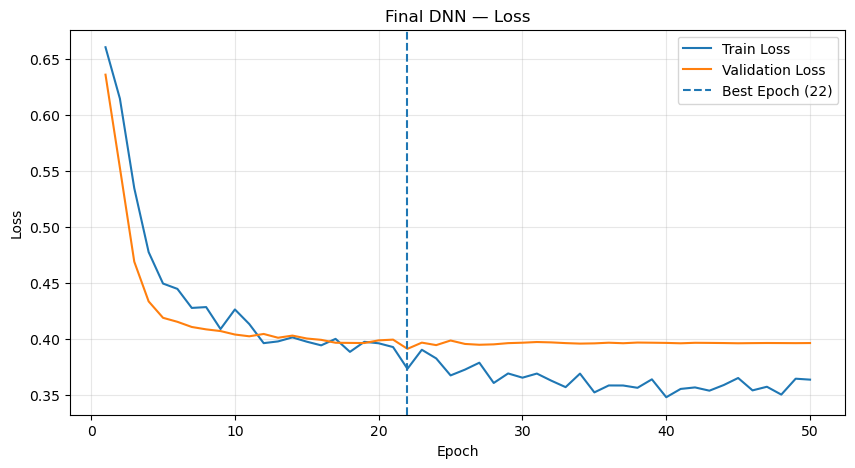

In [135]:
epochs_range = range(1, FINAL_EPOCHS + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    final_train_loss,
    label="Train Loss"
)

plt.plot(
    epochs_range,
    final_val_loss,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final DNN — Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

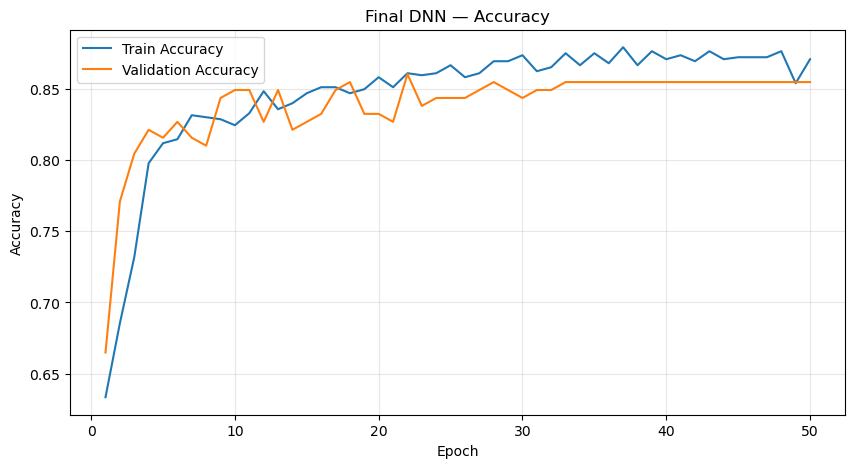

In [136]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    final_train_acc,
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    final_val_acc,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final DNN — Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Вывод по обучению финальной DNN

Финальная модель быстро улучшала качество в начале обучения, после чего Validation Loss вышел на плато.

Минимальный Validation Loss составил **0.3913** и был получен на **22-й эпохе**.

Максимальная Validation Accuracy также была получена на **22-й эпохе** и составила **0.8603**.

После этого Train Loss продолжал снижаться, тогда как качество на validation существенно не улучшалось.

В качестве финального состояния модели были сохранены веса с минимальным Validation Loss.

In [137]:
# Получим предсказания финальной модели
final_model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for X_batch, y_batch in valid_loader_final:

        logits = final_model(X_batch)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        y_true.extend(y_batch.cpu().numpy().flatten())
        y_pred.extend(predictions.cpu().numpy().flatten())

In [138]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

final_accuracy = accuracy_score(y_true, y_pred)
final_precision = precision_score(y_true, y_pred)
final_recall = recall_score(y_true, y_pred)
final_f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy:  0.8603
Precision: 0.8793
Recall:    0.7391
F1-score:  0.8031

Confusion Matrix:
[[103   7]
 [ 18  51]]


#### Итоговая оценка финальной DNN

Финальная модель показала следующие результаты на validation выборке:

- **Accuracy:** 0.8603
- **Precision:** 0.8793
- **Recall:** 0.7391
- **F1-score:** 0.8031

Модель правильно классифицировала 103 пассажиров класса `0` и 51 пассажира класса `1`.

При этом 7 пассажиров класса `0` были ошибочно отнесены к классу `1`, а 18 пассажиров класса `1` — к классу `0`.

Модель показывает высокую Precision, однако Recall для класса `1` остается несколько ниже.

### 8.11 DNN с Embedding для категориальных признаков

В предыдущей DNN категориальные признаки преобразовывались с помощью One-Hot Encoding.

Теперь попробуем использовать `Embedding`. Вместо создания отдельного бинарного столбца для каждой категории будем кодировать категории целочисленными индексами, для которых нейронная сеть будет обучать собственные векторные представления.

Числовые и категориальные признаки будем обрабатывать отдельно, а затем объединим числовые признаки с полученными embeddings внутри нейронной сети.

#### Подготовка данных для Embedding

Для модели с Embedding изменим способ обработки категориальных признаков.

Числовые признаки обработаем отдельно: пропущенные значения заполним медианой и выполним масштабирование с помощью `StandardScaler`.

Категориальные признаки вместо One-Hot Encoding преобразуем в целочисленные индексы. Каждый такой индекс будет использоваться соответствующим слоем `Embedding`.

Признак `Family_Size_Grouped`, который ранее кодировался отдельно с помощью Ordinal Encoding, также будем рассматривать как категориальный признак и передавать в Embedding.

In [139]:
# Числовые признаки
embedding_num_cols = num_cols.copy()

# Категориальные признаки
embedding_cat_cols = ohe_cols + ode_cols

print("Числовые признаки:")
print(embedding_num_cols)

print("\nКатегориальные признаки:")
print(embedding_cat_cols)

Числовые признаки:
['Age', 'Fare', 'Pclass', 'Family_Size', 'Cabin_known', 'Cabin_count']

Категориальные признаки:
['Sex', 'Embarked', 'Title', 'Deck', 'Age_Bin', 'Fare_Bin', 'Family_Size_Grouped']


In [140]:
# Preprocessor для числовых признаков
embedding_num_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor для категориальных признаков
embedding_cat_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

#### Преобразование данных

Обучим числовой и категориальный preprocessors только на обучающей выборке.

После Ordinal Encoding сдвинем индексы категорий на `+1`. Благодаря этому индекс `0` будет зарезервирован для неизвестных категорий, а известные категории будут иметь индексы начиная с `1`.

In [141]:
# Обработаем числовые признаки
X_train_numeric = embedding_num_preprocessor.fit_transform(
    X_train[embedding_num_cols]
)

X_valid_numeric = embedding_num_preprocessor.transform(
    X_valid[embedding_num_cols]
)


# Обработаем категориальные признаки
X_train_categorical = embedding_cat_preprocessor.fit_transform(
    X_train[embedding_cat_cols]
)

X_valid_categorical = embedding_cat_preprocessor.transform(
    X_valid[embedding_cat_cols]
)


# Сдвинем индексы категорий на 1
X_train_categorical = X_train_categorical + 1
X_valid_categorical = X_valid_categorical + 1


print("Numeric:")
print("Train:", X_train_numeric.shape)
print("Validation:", X_valid_numeric.shape)

print("\nCategorical:")
print("Train:", X_train_categorical.shape)
print("Validation:", X_valid_categorical.shape)

Numeric:
Train: (712, 6)
Validation: (179, 6)

Categorical:
Train: (712, 7)
Validation: (179, 7)


In [142]:
# Определим количество категорий для каждого категориального признака
category_sizes = [
    len(categories) + 1
    for categories in embedding_cat_preprocessor
        .named_steps['encoder']
        .categories_
]

for feature, size in zip(embedding_cat_cols, category_sizes):
    print(f"{feature}: {size}")

Sex: 3
Embarked: 4
Title: 9
Deck: 9
Age_Bin: 9
Fare_Bin: 7
Family_Size_Grouped: 5


#### Размерность Embedding

Для каждого категориального признака создадим отдельный Embedding-слой.

Размерность Embedding выберем в зависимости от количества категорий. Для этого используем практическое правило:

`embedding_dim = min(50, (category_size + 1) // 2)`

Таким образом, признаки с небольшим количеством категорий будут представлены небольшими обучаемыми векторами.

In [143]:
# Определим размер Embedding для каждого категориального признака
embedding_dims = [
    min(50, (size + 1) // 2)
    for size in category_sizes
]

for feature, size, dim in zip(
    embedding_cat_cols,
    category_sizes,
    embedding_dims
):
    print(
        f"{feature}: "
        f"categories = {size}, "
        f"embedding_dim = {dim}"
    )

Sex: categories = 3, embedding_dim = 2
Embarked: categories = 4, embedding_dim = 2
Title: categories = 9, embedding_dim = 5
Deck: categories = 9, embedding_dim = 5
Age_Bin: categories = 9, embedding_dim = 5
Fare_Bin: categories = 7, embedding_dim = 4
Family_Size_Grouped: categories = 5, embedding_dim = 3


#### Преобразование данных в тензоры

Преобразуем числовые и категориальные признаки в отдельные PyTorch-тензоры.

Числовые признаки будем хранить в формате `float32`, а индексы категориальных признаков — в формате `long`, который требуется слоям `Embedding`.

In [144]:
# Преобразуем числовые признаки в тензоры
X_train_numeric_tensor = torch.tensor(
    X_train_numeric,
    dtype=torch.float32
)

X_valid_numeric_tensor = torch.tensor(
    X_valid_numeric,
    dtype=torch.float32
)


# Преобразуем индексы категорий в целочисленные тензоры
X_train_categorical_tensor = torch.tensor(
    X_train_categorical,
    dtype=torch.long
)

X_valid_categorical_tensor = torch.tensor(
    X_valid_categorical,
    dtype=torch.long
)


print("Numeric:")
print("Train:", X_train_numeric_tensor.shape)
print("Validation:", X_valid_numeric_tensor.shape)

print("\nCategorical:")
print("Train:", X_train_categorical_tensor.shape)
print("Validation:", X_valid_categorical_tensor.shape)

Numeric:
Train: torch.Size([712, 6])
Validation: torch.Size([179, 6])

Categorical:
Train: torch.Size([712, 7])
Validation: torch.Size([179, 7])


#### Создание DataLoader

Создадим отдельные `TensorDataset` и `DataLoader` для модели с Embedding.

Каждый объект датасета будет содержать числовые признаки, индексы категориальных признаков и целевую переменную.

In [145]:
# Создадим датасеты
train_embedding_dataset = TensorDataset(
    X_train_numeric_tensor,
    X_train_categorical_tensor,
    y_train_tensor
)

valid_embedding_dataset = TensorDataset(
    X_valid_numeric_tensor,
    X_valid_categorical_tensor,
    y_valid_tensor
)


# Создадим DataLoader
EMBEDDING_BATCH_SIZE = 16

train_embedding_loader = DataLoader(
    train_embedding_dataset,
    batch_size=EMBEDDING_BATCH_SIZE,
    shuffle=True
)

valid_embedding_loader = DataLoader(
    valid_embedding_dataset,
    batch_size=EMBEDDING_BATCH_SIZE,
    shuffle=False
)


print("Количество train batches:", len(train_embedding_loader))
print("Количество validation batches:", len(valid_embedding_loader))

Количество train batches: 45
Количество validation batches: 12


#### Модель DNN с Embedding

Для каждого категориального признака создадим отдельный слой `Embedding`.

Полученные embedding-векторы объединим между собой, после чего добавим к ним числовые признаки. Полученный общий вектор передадим в полносвязную нейронную сеть.

Для более корректного сравнения с финальной DNN сохраним ту же основную архитектуру скрытых слоев: `32 → 16`, `LeakyReLU` и `Dropout = 0.3`.

In [146]:
class TitanicEmbeddingDNN(nn.Module):

    def __init__(
        self,
        num_numeric_features,
        category_sizes,
        embedding_dims
    ):
        super().__init__()

        # Создадим отдельный Embedding для каждого категориального признака
        self.embeddings = nn.ModuleList([
            nn.Embedding(category_size, embedding_dim)
            for category_size, embedding_dim
            in zip(category_sizes, embedding_dims)
        ])

        # Общий размер всех Embedding
        total_embedding_dim = sum(embedding_dims)

        # Размер входа в полносвязную часть сети
        input_size = num_numeric_features + total_embedding_dim

        self.fc1 = nn.Linear(input_size, 32)
        self.activation1 = nn.LeakyReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(32, 16)
        self.activation2 = nn.LeakyReLU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(16, 1)


    def forward(self, x_numeric, x_categorical):

        # Получим Embedding для каждого категориального признака
        embedded = [
            embedding(x_categorical[:, i])
            for i, embedding in enumerate(self.embeddings)
        ]

        # Объединим все Embedding в один вектор
        x = torch.cat(embedded, dim=1)

        # Добавим числовые признаки
        x = torch.cat([x_numeric, x], dim=1)

        # Полносвязная часть сети
        x = self.fc1(x)
        x = self.activation1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.activation2(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

In [147]:
# Количество числовых признаков
num_numeric_features = X_train_numeric_tensor.shape[1]

# Создадим модель
embedding_model = TitanicEmbeddingDNN(
    num_numeric_features=num_numeric_features,
    category_sizes=category_sizes,
    embedding_dims=embedding_dims
)

print(embedding_model)

TitanicEmbeddingDNN(
  (embeddings): ModuleList(
    (0): Embedding(3, 2)
    (1): Embedding(4, 2)
    (2-4): 3 x Embedding(9, 5)
    (5): Embedding(7, 4)
    (6): Embedding(5, 3)
  )
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (activation1): LeakyReLU(negative_slope=0.01)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (activation2): LeakyReLU(negative_slope=0.01)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
)


In [148]:
# Возьмем один batch
X_numeric_batch, X_categorical_batch, y_batch = next(
    iter(train_embedding_loader)
)

# Получим выход модели
logits = embedding_model(
    X_numeric_batch,
    X_categorical_batch
)

print("Numeric batch:", X_numeric_batch.shape)
print("Categorical batch:", X_categorical_batch.shape)
print("Target batch:", y_batch.shape)
print("Model output:", logits.shape)

Numeric batch: torch.Size([16, 6])
Categorical batch: torch.Size([16, 7])
Target batch: torch.Size([16, 1])
Model output: torch.Size([16, 1])


#### Настройка обучения модели

Для обучения DNN с Embedding используем те же основные параметры, что и для финальной обычной DNN:

- функцию потерь `BCEWithLogitsLoss`;
- optimizer `Adam`;
- начальный `learning_rate = 0.001`;
- scheduler `ReduceLROnPlateau`;
- максимальное количество эпох — `50`.

Во время обучения будем сохранять веса модели с минимальным Validation Loss.

In [149]:
embedding_loss_fn = nn.BCEWithLogitsLoss()

embedding_optimizer = torch.optim.Adam(
    embedding_model.parameters(),
    lr=0.001
)

embedding_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    embedding_optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

EMBEDDING_EPOCHS = 50

In [150]:
# История обучения
embedding_train_loss = []
embedding_train_acc = []

embedding_val_loss = []
embedding_val_acc = []

# Лучший результат
best_embedding_val_loss = float("inf")
best_embedding_epoch = 0
best_embedding_model_state = None


for epoch in range(EMBEDDING_EPOCHS):

    # --------------------
    # Обучение
    # --------------------

    embedding_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_numeric_batch, X_categorical_batch, y_batch in train_embedding_loader:

        embedding_optimizer.zero_grad()

        logits = embedding_model(
            X_numeric_batch,
            X_categorical_batch
        )

        loss = embedding_loss_fn(logits, y_batch)

        loss.backward()
        embedding_optimizer.step()

        running_loss += loss.item() * X_numeric_batch.size(0)

        predictions = (torch.sigmoid(logits) >= 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    embedding_train_loss.append(epoch_train_loss)
    embedding_train_acc.append(epoch_train_acc)

    # --------------------
    # Валидация
    # --------------------

    embedding_model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_numeric_batch, X_categorical_batch, y_batch in valid_embedding_loader:

            logits = embedding_model(
                X_numeric_batch,
                X_categorical_batch
            )

            loss = embedding_loss_fn(logits, y_batch)

            running_loss += loss.item() * X_numeric_batch.size(0)

            predictions = (torch.sigmoid(logits) >= 0.5).float()

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_val_loss = running_loss / total
    epoch_val_acc = correct / total

    embedding_val_loss.append(epoch_val_loss)
    embedding_val_acc.append(epoch_val_acc)

    # --------------------
    # Сохраним лучшие веса
    # --------------------

    if epoch_val_loss < best_embedding_val_loss:

        best_embedding_val_loss = epoch_val_loss
        best_embedding_epoch = epoch + 1

        best_embedding_model_state = copy.deepcopy(
            embedding_model.state_dict()
        )

    # --------------------
    # Scheduler
    # --------------------

    embedding_scheduler.step(epoch_val_loss)

    current_lr = embedding_optimizer.param_groups[0]["lr"]

    # --------------------
    # Результаты эпохи
    # --------------------

    print(
        f"Epoch [{epoch + 1}/{EMBEDDING_EPOCHS}] "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )


# Вернем модели лучшие веса
embedding_model.load_state_dict(
    best_embedding_model_state
)

Epoch [1/50] Train Loss: 0.6593 | Train Acc: 0.6447 | Val Loss: 0.6135 | Val Acc: 0.7486 | LR: 0.001000
Epoch [2/50] Train Loss: 0.5756 | Train Acc: 0.7472 | Val Loss: 0.5074 | Val Acc: 0.7989 | LR: 0.001000
Epoch [3/50] Train Loss: 0.5088 | Train Acc: 0.7697 | Val Loss: 0.4509 | Val Acc: 0.8101 | LR: 0.001000
Epoch [4/50] Train Loss: 0.4680 | Train Acc: 0.8104 | Val Loss: 0.4343 | Val Acc: 0.8212 | LR: 0.001000
Epoch [5/50] Train Loss: 0.4421 | Train Acc: 0.8230 | Val Loss: 0.4222 | Val Acc: 0.8212 | LR: 0.001000
Epoch [6/50] Train Loss: 0.4343 | Train Acc: 0.8202 | Val Loss: 0.4188 | Val Acc: 0.8212 | LR: 0.001000
Epoch [7/50] Train Loss: 0.4328 | Train Acc: 0.8329 | Val Loss: 0.4172 | Val Acc: 0.8324 | LR: 0.001000
Epoch [8/50] Train Loss: 0.4388 | Train Acc: 0.8301 | Val Loss: 0.4163 | Val Acc: 0.8212 | LR: 0.001000
Epoch [9/50] Train Loss: 0.4258 | Train Acc: 0.8357 | Val Loss: 0.4156 | Val Acc: 0.8268 | LR: 0.001000
Epoch [10/50] Train Loss: 0.4178 | Train Acc: 0.8244 | Val Loss:

<All keys matched successfully>

In [151]:
print("Best Epoch:", best_embedding_epoch)
print(f"Best Val Loss: {best_embedding_val_loss:.4f}")
print(
    f"Val Accuracy on Best Epoch: "
    f"{embedding_val_acc[best_embedding_epoch - 1]:.4f}"
)

print(
    f"\nBest Val Accuracy: "
    f"{max(embedding_val_acc):.4f}"
)

print(
    "Best Accuracy Epoch:",
    embedding_val_acc.index(max(embedding_val_acc)) + 1
)

Best Epoch: 17
Best Val Loss: 0.4085
Val Accuracy on Best Epoch: 0.8212

Best Val Accuracy: 0.8324
Best Accuracy Epoch: 7


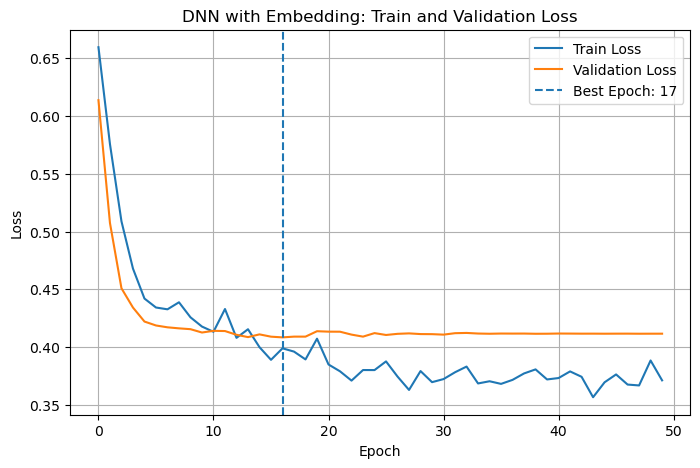

In [152]:
plt.figure(figsize=(8, 5))

plt.plot(
    embedding_train_loss,
    label="Train Loss"
)

plt.plot(
    embedding_val_loss,
    label="Validation Loss"
)

plt.axvline(
    best_embedding_epoch - 1,
    linestyle="--",
    label=f"Best Epoch: {best_embedding_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DNN with Embedding: Train and Validation Loss")

plt.legend()
plt.grid()

plt.show()

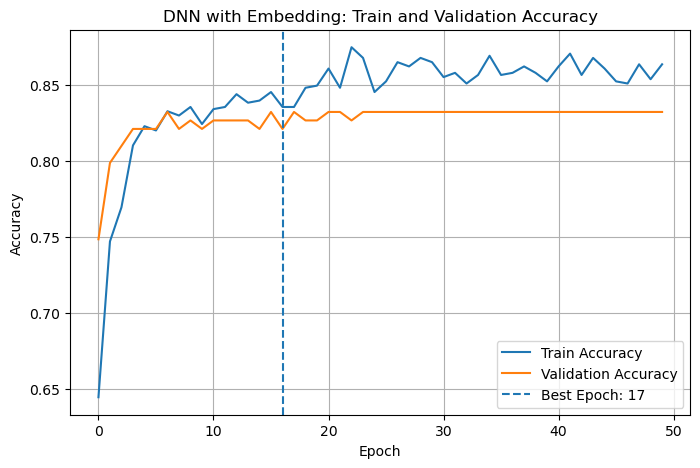

In [153]:
plt.figure(figsize=(8, 5))

plt.plot(
    embedding_train_acc,
    label="Train Accuracy"
)

plt.plot(
    embedding_val_acc,
    label="Validation Accuracy"
)

plt.axvline(
    best_embedding_epoch - 1,
    linestyle="--",
    label=f"Best Epoch: {best_embedding_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DNN with Embedding: Train and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

#### Вывод по обучению DNN с Embedding

Модель с Embedding быстро улучшала качество в начале обучения, после чего Validation Loss вышел на плато.

Минимальный Validation Loss составил **0.4085** и был получен на **17-й эпохе**. Accuracy на этой эпохе составила **0.8212**.

Максимальная Validation Accuracy была достигнута раньше, на **7-й эпохе**, и составила **0.8324**.

Для финального состояния модели, как и для обычной DNN, были сохранены веса с минимальным Validation Loss.

In [154]:
embedding_model.eval()

embedding_y_true = []
embedding_y_pred = []

with torch.no_grad():

    for X_numeric_batch, X_categorical_batch, y_batch in valid_embedding_loader:

        logits = embedding_model(
            X_numeric_batch,
            X_categorical_batch
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        embedding_y_true.extend(
            y_batch.cpu().numpy().flatten()
        )

        embedding_y_pred.extend(
            predictions.cpu().numpy().flatten()
        )

In [155]:
embedding_accuracy = accuracy_score(
    embedding_y_true,
    embedding_y_pred
)

embedding_precision = precision_score(
    embedding_y_true,
    embedding_y_pred
)

embedding_recall = recall_score(
    embedding_y_true,
    embedding_y_pred
)

embedding_f1 = f1_score(
    embedding_y_true,
    embedding_y_pred
)

print(f"Accuracy:  {embedding_accuracy:.4f}")
print(f"Precision: {embedding_precision:.4f}")
print(f"Recall:    {embedding_recall:.4f}")
print(f"F1-score:  {embedding_f1:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        embedding_y_true,
        embedding_y_pred
    )
)

Accuracy:  0.8212
Precision: 0.7606
Recall:    0.7826
F1-score:  0.7714

Confusion Matrix:
[[93 17]
 [15 54]]


#### Итоговая оценка DNN с Embedding

Модель с Embedding показала следующие результаты на validation выборке:

- **Accuracy:** 0.8212
- **Precision:** 0.7606
- **Recall:** 0.7826
- **F1-score:** 0.7714

Модель правильно классифицировала 93 пассажиров класса `0` и 54 пассажиров класса `1`.

При этом 17 пассажиров класса `0` были ошибочно отнесены к классу `1`, а 15 пассажиров класса `1` — к классу `0`.

На данном фиксированном train/validation split модель с Embedding показала меньшие Accuracy, Precision и F1-score, чем обычная DNN, но более высокий Recall.

Это показывает, что результат одного разбиения недостаточен для надежного сравнения нейронных сетей, поэтому далее проведем cross-validation.

#### Сохранение модели

Сохраним веса обученной DNN с Embedding для дальнейшего использования.

In [156]:
torch.save(
    embedding_model.state_dict(),
    "titanic_embedding_dnn.pth"
)

print("Модель сохранена.")

Модель сохранена.


#### Итог по DNN

В рамках раздела были последовательно исследованы различные варианты архитектуры и параметров нейронной сети: количество и размер скрытых слоев, Batch Normalization, Dropout, функции активации, optimizer, learning rate, batch size, количество эпох и scheduler.

На основе проведенных экспериментов была построена финальная DNN с двумя скрытыми слоями `32 → 16`, `LeakyReLU`, `Dropout = 0.3`, optimizer `Adam` и scheduler `ReduceLROnPlateau`.

Дополнительно была построена модель с Embedding для категориальных признаков.

Финальная обычная DNN показала:

- **Accuracy:** 0.8603
- **Precision:** 0.8793
- **Recall:** 0.7391
- **F1-score:** 0.8031

DNN с Embedding показала:

- **Accuracy:** 0.8212
- **Precision:** 0.7606
- **Recall:** 0.7826
- **F1-score:** 0.7714

На фиксированной validation выборке обычная DNN показала более высокие Accuracy, Precision и F1-score, тогда как DNN с Embedding получила более высокий Recall.

Поскольку результаты нейронных сетей зависят от конкретного разбиения данных и случайной инициализации весов, для итогового сравнения далее используем 5-fold cross-validation.

### 8.12 Кросс-валидация финальных DNN

Для более надежной оценки качества финальных нейронных сетей проведем 5-fold cross-validation.

Архитектуру и параметры моделей изменять не будем: кросс-валидация используется только для оценки уже выбранных моделей.

На каждой итерации preprocessing и нейронная сеть будут обучаться заново только на обучающей части соответствующего fold. Это позволит избежать утечки данных между train и validation.

Для сохранения соотношения классов используем `StratifiedKFold`.

In [157]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

dnn_cv_scores = []

In [158]:
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):

    print(f"\nFold {fold}/5")

    # Разделим данные текущего fold
    X_fold_train = X.iloc[train_idx]
    X_fold_valid = X.iloc[valid_idx]

    y_fold_train = y.iloc[train_idx]
    y_fold_valid = y.iloc[valid_idx]

    # Создадим отдельный preprocessor для текущего fold
    fold_preprocessor = copy.deepcopy(preprocessor)

    X_fold_train_processed = fold_preprocessor.fit_transform(
        X_fold_train
    )

    X_fold_valid_processed = fold_preprocessor.transform(
        X_fold_valid
    )

    # Преобразуем данные в тензоры
    X_fold_train_tensor = torch.tensor(
        X_fold_train_processed,
        dtype=torch.float32
    )

    X_fold_valid_tensor = torch.tensor(
        X_fold_valid_processed,
        dtype=torch.float32
    )

    y_fold_train_tensor = torch.tensor(
        y_fold_train.values,
        dtype=torch.float32
    ).unsqueeze(1)

    y_fold_valid_tensor = torch.tensor(
        y_fold_valid.values,
        dtype=torch.float32
    ).unsqueeze(1)

    # Создадим Dataset и DataLoader
    fold_train_dataset = TensorDataset(
        X_fold_train_tensor,
        y_fold_train_tensor
    )

    fold_valid_dataset = TensorDataset(
        X_fold_valid_tensor,
        y_fold_valid_tensor
    )

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=16,
        shuffle=True
    )

    fold_valid_loader = DataLoader(
        fold_valid_dataset,
        batch_size=16,
        shuffle=False
    )

    # На каждом fold создаем новую модель
    fold_model = FinalTitanicDNN(
        input_size=X_fold_train_tensor.shape[1]
    )

    fold_loss_fn = nn.BCEWithLogitsLoss()

    fold_optimizer = torch.optim.Adam(
        fold_model.parameters(),
        lr=0.001
    )

    fold_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        fold_optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_val_loss = float("inf")
    best_model_state = None

    # Обучение модели
    for epoch in range(FINAL_EPOCHS):

        fold_model.train()

        for X_batch, y_batch in fold_train_loader:

            fold_optimizer.zero_grad()

            logits = fold_model(X_batch)

            loss = fold_loss_fn(
                logits,
                y_batch
            )

            loss.backward()
            fold_optimizer.step()

        # Validation Loss
        fold_model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in fold_valid_loader:

                logits = fold_model(X_batch)

                loss = fold_loss_fn(
                    logits,
                    y_batch
                )

                val_loss += loss.item() * X_batch.size(0)

        val_loss /= len(fold_valid_dataset)

        fold_scheduler.step(val_loss)

        # Сохраним лучшие веса текущего fold
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model_state = copy.deepcopy(
                fold_model.state_dict()
            )

    # Вернем лучшие веса
    fold_model.load_state_dict(best_model_state)

    # Оценим Accuracy
    fold_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in fold_valid_loader:

            logits = fold_model(X_batch)

            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

    fold_accuracy = correct / total

    dnn_cv_scores.append(fold_accuracy)

    print(
        f"Best Val Loss: {best_val_loss:.4f} | "
        f"Accuracy: {fold_accuracy:.4f}"
    )


Fold 1/5
Best Val Loss: 0.4179 | Accuracy: 0.8380

Fold 2/5
Best Val Loss: 0.4344 | Accuracy: 0.8090

Fold 3/5
Best Val Loss: 0.4251 | Accuracy: 0.8315

Fold 4/5
Best Val Loss: 0.4322 | Accuracy: 0.7921

Fold 5/5
Best Val Loss: 0.3756 | Accuracy: 0.8427


In [159]:
dnn_cv_mean = np.mean(dnn_cv_scores)
dnn_cv_std = np.std(dnn_cv_scores)

print(f"DNN CV Accuracy: {dnn_cv_mean:.4f}")
print(f"DNN CV STD: {dnn_cv_std:.4f}")

DNN CV Accuracy: 0.8227
DNN CV STD: 0.0191


#### Результат кросс-валидации DNN

По результатам 5-fold cross-validation средняя Accuracy финальной DNN составила **0.8227**, стандартное отклонение — **0.0191**.

Результаты отдельных folds находятся в диапазоне от **0.7921** до **0.8427**, что показывает заметную зависимость качества нейронной сети от конкретного разбиения данных.

На фиксированной validation выборке модель показала более высокий результат — **0.8603**.

Разница между результатом одного разбиения и средней cross-validation подтверждает, что для итоговой оценки модели надежнее использовать результаты нескольких folds.

In [160]:
embedding_cv_scores = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):

    print(f"\nFold {fold}/5")

    # Разделим данные текущего fold
    X_fold_train = X.iloc[train_idx]
    X_fold_valid = X.iloc[valid_idx]

    y_fold_train = y.iloc[train_idx]
    y_fold_valid = y.iloc[valid_idx]

    # Создадим отдельные preprocessors для текущего fold
    fold_num_preprocessor = copy.deepcopy(
        embedding_num_preprocessor
    )

    fold_cat_preprocessor = copy.deepcopy(
        embedding_cat_preprocessor
    )

    # Числовые признаки
    X_fold_train_numeric = fold_num_preprocessor.fit_transform(
        X_fold_train[embedding_num_cols]
    )

    X_fold_valid_numeric = fold_num_preprocessor.transform(
        X_fold_valid[embedding_num_cols]
    )

    # Категориальные признаки
    X_fold_train_categorical = fold_cat_preprocessor.fit_transform(
        X_fold_train[embedding_cat_cols]
    )

    X_fold_valid_categorical = fold_cat_preprocessor.transform(
        X_fold_valid[embedding_cat_cols]
    )

    # Индекс 0 оставляем для неизвестных категорий
    X_fold_train_categorical += 1
    X_fold_valid_categorical += 1

    # Определим количество категорий для каждого признака
    fold_category_sizes = [
        len(categories) + 1
        for categories in fold_cat_preprocessor
            .named_steps["encoder"]
            .categories_
    ]

    # Размеры Embedding
    fold_embedding_dims = [
        min(50, (size + 1) // 2)
        for size in fold_category_sizes
    ]

    # Преобразуем данные в тензоры
    X_fold_train_numeric_tensor = torch.tensor(
        X_fold_train_numeric,
        dtype=torch.float32
    )

    X_fold_valid_numeric_tensor = torch.tensor(
        X_fold_valid_numeric,
        dtype=torch.float32
    )

    X_fold_train_categorical_tensor = torch.tensor(
        X_fold_train_categorical,
        dtype=torch.long
    )

    X_fold_valid_categorical_tensor = torch.tensor(
        X_fold_valid_categorical,
        dtype=torch.long
    )

    y_fold_train_tensor = torch.tensor(
        y_fold_train.values,
        dtype=torch.float32
    ).unsqueeze(1)

    y_fold_valid_tensor = torch.tensor(
        y_fold_valid.values,
        dtype=torch.float32
    ).unsqueeze(1)

    # Dataset
    fold_train_dataset = TensorDataset(
        X_fold_train_numeric_tensor,
        X_fold_train_categorical_tensor,
        y_fold_train_tensor
    )

    fold_valid_dataset = TensorDataset(
        X_fold_valid_numeric_tensor,
        X_fold_valid_categorical_tensor,
        y_fold_valid_tensor
    )

    # DataLoader
    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=16,
        shuffle=True
    )

    fold_valid_loader = DataLoader(
        fold_valid_dataset,
        batch_size=16,
        shuffle=False
    )

    # На каждом fold создаем новую модель
    fold_model = TitanicEmbeddingDNN(
        num_numeric_features=X_fold_train_numeric_tensor.shape[1],
        category_sizes=fold_category_sizes,
        embedding_dims=fold_embedding_dims
    )

    fold_loss_fn = nn.BCEWithLogitsLoss()

    fold_optimizer = torch.optim.Adam(
        fold_model.parameters(),
        lr=0.001
    )

    fold_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        fold_optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_val_loss = float("inf")
    best_model_state = None

    # Обучение
    for epoch in range(EMBEDDING_EPOCHS):

        fold_model.train()

        for X_numeric_batch, X_categorical_batch, y_batch in fold_train_loader:

            fold_optimizer.zero_grad()

            logits = fold_model(
                X_numeric_batch,
                X_categorical_batch
            )

            loss = fold_loss_fn(
                logits,
                y_batch
            )

            loss.backward()
            fold_optimizer.step()

        # Validation
        fold_model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for X_numeric_batch, X_categorical_batch, y_batch in fold_valid_loader:

                logits = fold_model(
                    X_numeric_batch,
                    X_categorical_batch
                )

                loss = fold_loss_fn(
                    logits,
                    y_batch
                )

                val_loss += (
                    loss.item() * y_batch.size(0)
                )

        val_loss /= len(fold_valid_dataset)

        fold_scheduler.step(val_loss)

        # Сохраним лучшие веса текущего fold
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model_state = copy.deepcopy(
                fold_model.state_dict()
            )

    # Вернем лучшие веса текущего fold
    fold_model.load_state_dict(
        best_model_state
    )

    # Оценим Accuracy
    fold_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_numeric_batch, X_categorical_batch, y_batch in fold_valid_loader:

            logits = fold_model(
                X_numeric_batch,
                X_categorical_batch
            )

            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

    fold_accuracy = correct / total

    embedding_cv_scores.append(
        fold_accuracy
    )

    print(
        f"Best Val Loss: {best_val_loss:.4f} | "
        f"Accuracy: {fold_accuracy:.4f}"
    )


Fold 1/5
Best Val Loss: 0.4151 | Accuracy: 0.8324

Fold 2/5
Best Val Loss: 0.4363 | Accuracy: 0.8090

Fold 3/5
Best Val Loss: 0.4294 | Accuracy: 0.8315

Fold 4/5
Best Val Loss: 0.4109 | Accuracy: 0.8315

Fold 5/5
Best Val Loss: 0.3760 | Accuracy: 0.8371


In [161]:
embedding_cv_mean = np.mean(embedding_cv_scores)
embedding_cv_std = np.std(embedding_cv_scores)

print(f"Embedding DNN CV Accuracy: {embedding_cv_mean:.4f}")
print(f"Embedding DNN CV STD: {embedding_cv_std:.4f}")

Embedding DNN CV Accuracy: 0.8283
Embedding DNN CV STD: 0.0099


#### Результат кросс-валидации DNN с Embedding

По результатам 5-fold cross-validation средняя Accuracy DNN с Embedding составила **0.8283**, стандартное отклонение — **0.0099**.

Для обычной DNN средняя Accuracy составила **0.8227** при стандартном отклонении **0.0191**.

Таким образом, использование Embedding немного увеличило среднюю Accuracy и одновременно уменьшило разброс результатов между folds.

На фиксированной validation выборке ситуация была обратной: обычная DNN показала Accuracy **0.8603**, а DNN с Embedding — **0.8212**.

Это еще раз показывает сильную зависимость результата нейронной сети от конкретного разбиения данных. Поэтому для итогового сравнения моделей будем использовать результаты 5-fold cross-validation.

## 9. Итоговое сравнение моделей

После обучения и настройки всех рассмотренных моделей сравним их итоговое качество.

Для корректного сравнения будем использовать среднюю `Accuracy`, полученную с помощью 5-fold cross-validation. Для финальных DNN также была отдельно проведена 5-fold cross-validation с повторным обучением preprocessing и модели на каждом fold.

### 9.1 Сравнение результатов

In [162]:
# Добавим результаты DNN к общей таблице моделей
dnn_results = pd.DataFrame({
    'Model': [
        'DNN',
        'DNN + Embedding'
    ],
    'Accuracy': [
        dnn_cv_mean,
        embedding_cv_mean
    ]
})

final_results = pd.concat(
    [all_results, dnn_results],
    ignore_index=True
)

final_results = (
    final_results
    .sort_values('Accuracy', ascending=False)
    .reset_index(drop=True)
)

final_results

,Model,Accuracy
0,VotingClassifier hard,0.847360
1,XGBoost,0.845088
2,CatBoost,0.843996
3,GradientBoostingClassifier,0.842904
4,LightGBM,0.840631
5,VotingClassifier soft,0.840613
6,StackingClassifier RidgeClassifier,0.839514
7,StackingClassifier LogisticRegression,0.839508
8,RandomForestClassifier,0.835032
9,SVC,0.832779


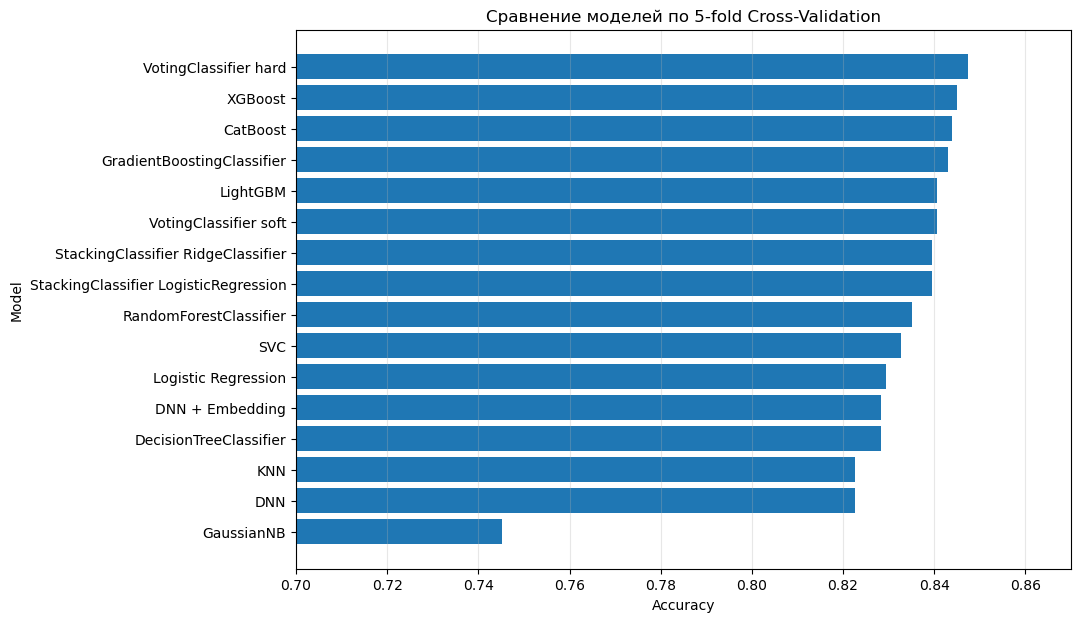

In [163]:
plt.figure(figsize=(10, 7))

plt.barh(
    final_results['Model'],
    final_results['Accuracy']
)

plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Сравнение моделей по 5-fold Cross-Validation')

plt.xlim(0.7, 0.87)

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.show()

### 9.2 Итоговый вывод

По результатам 5-fold cross-validation наилучшую среднюю Accuracy среди рассмотренных моделей показал **VotingClassifier hard — 0.8474**.

Близкие результаты получили модели бустинга:

- **XGBoost — 0.8451**
- **CatBoost — 0.8440**
- **GradientBoostingClassifier — 0.8429**
- **LightGBM — 0.8406**

Ансамблевые модели также показали высокое качество. Помимо лучшего `VotingClassifier hard`, результаты `VotingClassifier soft` и двух вариантов `StackingClassifier` находятся примерно на уровне **0.84 Accuracy**.

Финальная обычная DNN показала среднюю Accuracy **0.8227**, а DNN с Embedding — **0.8283**.

При этом стандартное отклонение уменьшилось с **0.0191** у обычной DNN до **0.0099** у DNN с Embedding, поэтому модель с Embedding показала более стабильные результаты между folds.

На фиксированной validation выборке обычная DNN показала Accuracy **0.8603**, а DNN с Embedding — **0.8212**. Отличие этих результатов от cross-validation показывает, что оценка нейронной сети по одному разбиению может быть нестабильной.

В целом нейронные сети не превзошли лучшие классические модели на данном датасете. Titanic представляет собой небольшой набор табличных данных, на котором методы бустинга и ансамбли показали более высокую среднюю Accuracy.

Использование Embedding для категориальных признаков при этом оказалось полезным по результатам cross-validation: средняя Accuracy немного увеличилась, а разброс между folds уменьшился.

По итогам проведенных экспериментов наибольшую среднюю Accuracy показал **VotingClassifier hard — 0.8474**.